# Tarea 01: Aproximación de una función desconocida

Generamos datos con una función que **nosotros definimos y ustedes no conocen**. Su
trabajo es reconstruirla a partir de los datos.

No es un acertijo: es lo que hace el machine learning todos los días. El capítulo 02
plantea el aprendizaje como **aproximación de funciones**, y aquí van a hacer
exactamente eso, con la ventaja rara de que existe una respuesta correcta y un límite
teórico al que se puede llegar.

## Lo que hay

- `train.csv`: 800 observaciones con 12 variables (`x1` a `x12`) y la respuesta `y`.
- `test.csv`: 400 observaciones con las mismas 12 variables, **sin** `y`.

Entregan sus 400 predicciones y un bot las califica automáticamente.

## Cómo se califica

| Su MSE en el conjunto de prueba | Calificación |
|---|---|
| Igual o peor que una regresión lineal con las 12 variables crudas | **5.0** |
| Igual al modelo bien especificado (el error irreducible) | **10.0** |
| En medio | proporcional a la mejora |

**El 5 está garantizado si entregan algo que corre.** El código del baseline se lo damos
hecho más abajo; de ahí para arriba es mérito suyo.

Tienen **3 intentos** de calificación. Un comentario `/validar` revisa el formato y les
dice cuál es su MSE objetivo **sin gastar intento**, así que úsenlo antes del primero.

## Qué se evalúa además del MSE

El MSE es la mitad. La otra mitad es la **Parte 5: la bitácora**, donde documentan cada
hipótesis que probaron — incluidas las que fallaron. Un notebook con buen MSE y bitácora
vacía vale poco: significa que no entendieron por qué funcionó.

---

## Las reglas sobre la IA

**Sí pueden usar IA. De hecho quiero que la usen.** Pero de una forma específica.

La IA no puede ver sus datos. Puede explicarles teoría, listarles técnicas o decirles qué
función de `matplotlib` usar. Lo que **no** puede hacer es mirar una gráfica de residuales
y decirles qué término falta, porque eso solo lo revela correr el código con *sus* datos, y
cada quien tiene datos distintos.

Así que la IA es su tutor, no su chofer. Para que sea tutor, péguenle esto al inicio de
cada conversación:

> Eres mi tutor de regresión, no mi resolvedor. Reglas: (1) no escribes código que yo
> pueda copiar; si te pido código, me devuelves el nombre de la función y su docstring.
> (2) No me das la respuesta: me preguntas qué espero ver y por qué. (3) Cuando me
> equivoque, no me corriges: me sugieres qué gráfica revelaría mi error. (4) Máximo
> tres oraciones por respuesta.

Y una regla para ustedes: **si la IA les da código y no pueden explicar qué hace línea
por línea, bórrenlo y escríbanlo ustedes.** Se nota en la bitácora, y se nota más en el
examen.

---
## Parte 0. Su variante

Cada quien tiene **datos distintos**: las 12 variables juegan papeles diferentes según
la persona. Copiar las predicciones de alguien más da un MSE malísimo. Comparar
*métodos* entre ustedes, en cambio, es buena idea y se los recomiendo.

Su carpeta de datos se identifica con su **clave única del ITAM**.

In [1]:
import hashlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 110
SEMILLA = 42

In [2]:
CLAVE_UNICA = "000218804"

# De la clave sale el nombre de su carpeta. No lo cambien a mano.
_clave = "".join(c for c in CLAVE_UNICA if c.isdigit()).zfill(9)
CARPETA = "v" + hashlib.sha256(_clave.encode()).hexdigest()[:8]

# Funciona corriendo el notebook desde `tareas/` o desde la raíz del repo
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "tareas/tarea_01_datos").exists())
MIS_DATOS = RAIZ / "tareas/tarea_01_datos" / CARPETA

assert CLAVE_UNICA, "Escriban su clave única en CLAVE_UNICA."
assert MIS_DATOS.exists(), (
    f"No existe la carpeta {CARPETA}. Revisen su clave única: si está mal escrita, "
    f"el nombre de la carpeta sale distinto y no van a encontrar sus datos."
)

train = pd.read_csv(MIS_DATOS / "train.csv")
test = pd.read_csv(MIS_DATOS / "test.csv")

VARIABLES = [f"x{i}" for i in range(1, 13)]
print(f"Su variante: {CARPETA}")
print(f"train: {train.shape}   test: {test.shape}")
train.head()


Su variante: vb81c45dc
train: (800, 13)   test: (400, 12)


,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,y
0,0.630826,0.236306,-1.800116,0.222597,0.841700,0.492952,2.643905,41.492289,1.212720,-2.136578,0.004773,-2.339191,-9.453410
1,0.748339,1.443458,-1.221849,11.464289,1.653205,-0.391573,-1.903807,61.690964,2.003661,0.343761,-0.307115,0.791852,10.869818
2,7.633728,-0.221542,1.335438,1.227997,-1.710326,0.388018,2.632250,53.118571,0.171794,0.894872,0.133764,1.206713,29.227143
3,2.294789,0.339232,1.020708,0.856483,0.765372,0.421822,1.265525,96.914344,3.347009,-0.872924,-0.307241,-0.450018,34.308347
4,0.911666,1.971838,-0.103434,2.144442,2.048848,0.247895,0.055908,85.262078,2.248371,-0.285813,0.168477,0.818956,41.143505


In [3]:
print(f"Faltantes en train: {train.isna().sum().sum()}")
print(f"Faltantes en test:  {test.isna().sum().sum()}")
train.describe().T


Faltantes en train: 0
Faltantes en test:  0


,count,mean,std,min,25%,50%,75%,max
x1,800.0,1.539975,1.795205,0.044116,0.503984,0.969328,1.920002,16.930100
x2,800.0,-0.014518,1.140651,-1.984964,-1.026556,0.047864,0.980544,1.993962
x3,800.0,0.020367,1.142014,-1.998820,-0.975479,0.019717,0.991326,1.998262
x4,800.0,1.626831,2.639321,0.032311,0.496648,0.940858,1.887838,47.672980
x5,800.0,-0.001714,1.761647,-2.979615,-1.547620,-0.010933,1.587143,2.999977
x6,800.0,0.016142,0.287387,-0.497491,-0.237787,0.034743,0.270936,0.499859
x7,800.0,-0.003882,1.007781,-3.328906,-0.703941,0.031117,0.712799,2.933746
x8,800.0,49.930668,29.201603,0.134054,25.303922,50.299079,74.773683,99.850785
x9,800.0,2.095877,1.141978,0.014028,1.128830,2.161350,3.086746,3.980633
x10,800.0,0.079503,0.953273,-3.117455,-0.495005,0.081404,0.691877,3.686781


### 0.1 El baseline que hay que ganar

Este es el modelo de referencia: una regresión lineal con las 12 variables **tal como
vienen**, sin transformar nada. Su MSE sobre el conjunto de prueba es, por definición, la
calificación **5.0**.

Se lo damos corrido para que arranquen sabiendo exactamente qué hay que superar.

In [4]:
X_train, X_val, y_train, y_val = train_test_split(
    train[VARIABLES], train["y"], test_size=0.25, random_state=SEMILLA
)

baseline = LinearRegression().fit(X_train, y_train)
mse_baseline = mean_squared_error(y_val, baseline.predict(X_val))

print(f"MSE del baseline en validación: {mse_baseline:.2f}")
print(f"R² del baseline en validación : {baseline.score(X_val, y_val):.3f}")
print(f"\nDesviación estándar de y: {train['y'].std():.2f}")

MSE del baseline en validación: 102.86
R² del baseline en validación : 0.454

Desviación estándar de y: 13.34


### 0.2 Cómo medir su progreso sin gastar intentos

Solo tienen 3 calificaciones, y necesitan medirse muchas más veces que eso. La solución
es la de siempre: **partir `train` en entrenamiento y validación**, ajustar en una parte
y medir en la otra. Eso ya lo hicimos en la celda anterior.

Dos advertencias importantes:

- Su MSE de validación **no** va a coincidir exactamente con el oficial. El oficial se
  mide sobre `test.csv`, que son otras 400 observaciones. Su número es una *estimación*
  del oficial, con su propia incertidumbre.
- Si eligen entre muchos modelos usando el mismo conjunto de validación, van a
  sobreajustar la validación. Para decisiones finas, usen validación cruzada
  (`cross_val_score`) en lugar de una sola partición.

**Nunca** ajusten nada usando `test.csv`: no tiene `y`, así que ni podrían — y ese es
justo el punto.

---
## Parte 1. Exploración

Antes de modelar, mírenlos. El objetivo de esta parte **no** es encontrar la respuesta,
es formarse sospechas que después van a confirmar o descartar.

Tres cosas que vale la pena graficar:

1. La distribución de cada variable por separado.
2. `y` contra cada variable, una gráfica por variable.
3. La matriz de correlación.

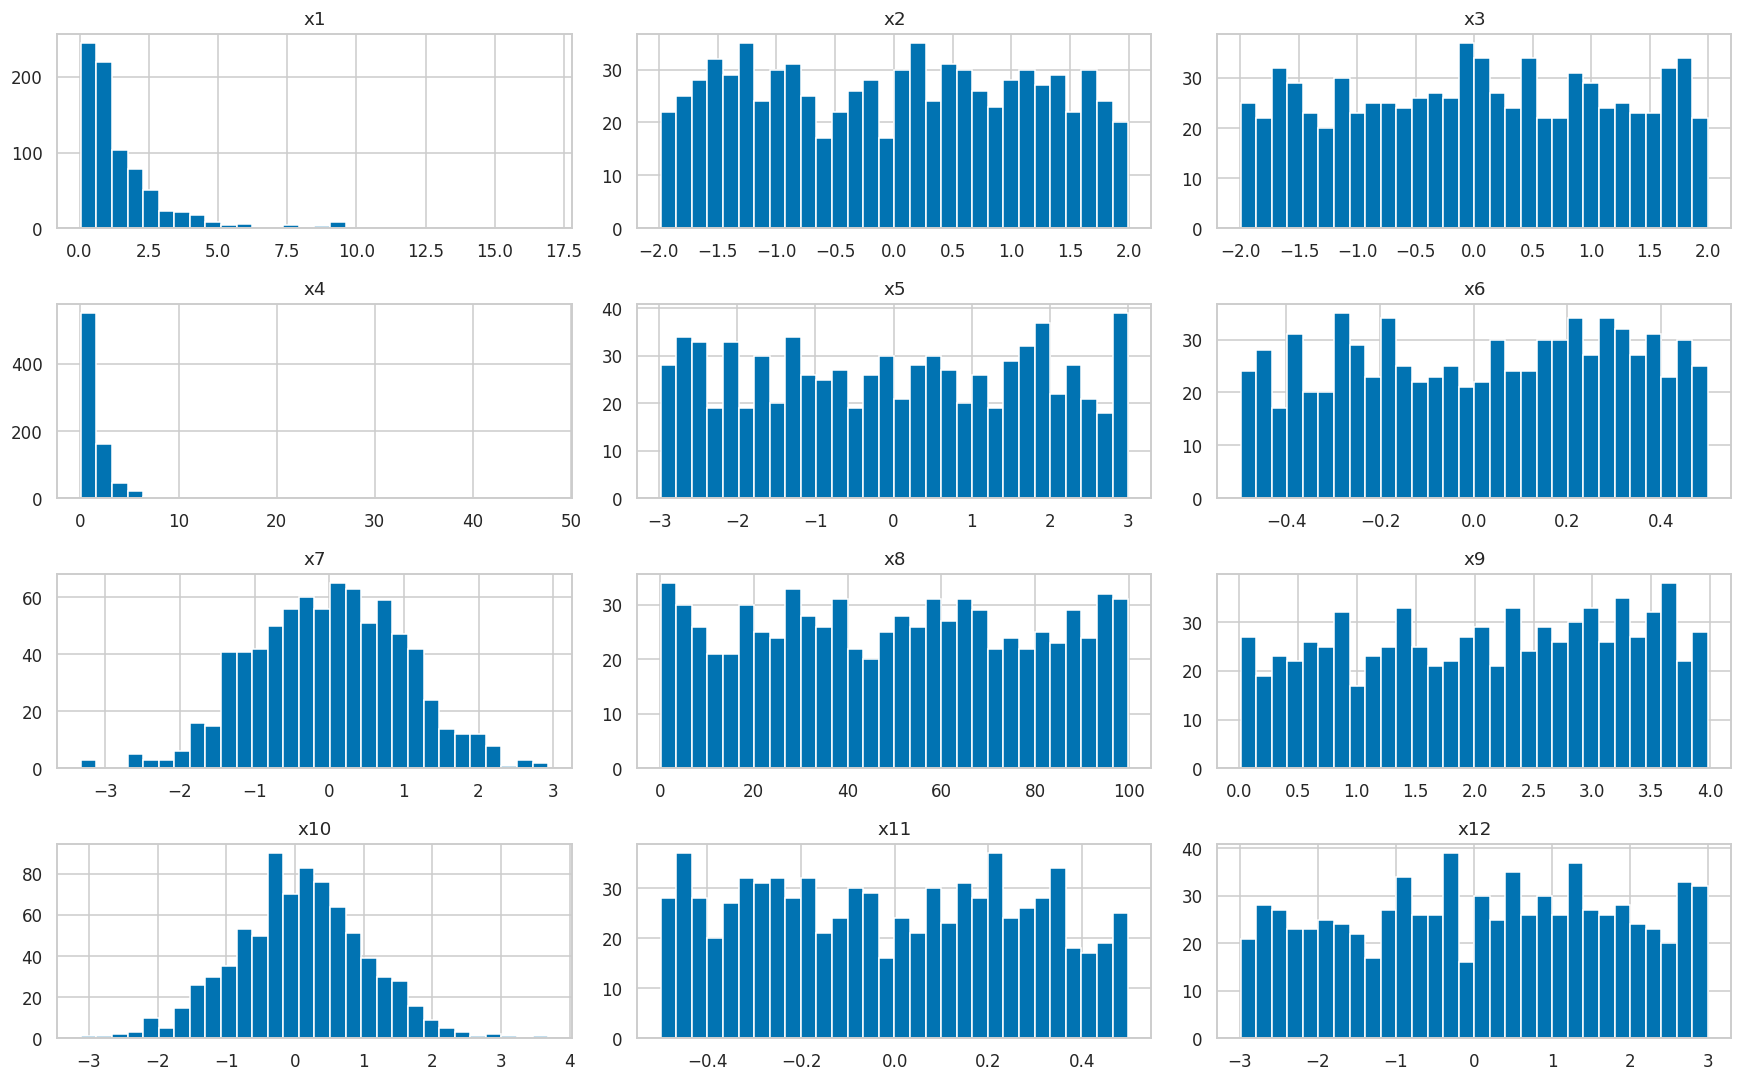

In [5]:
train[VARIABLES].hist(figsize=(16, 10), bins=30)
plt.tight_layout()
plt.show()


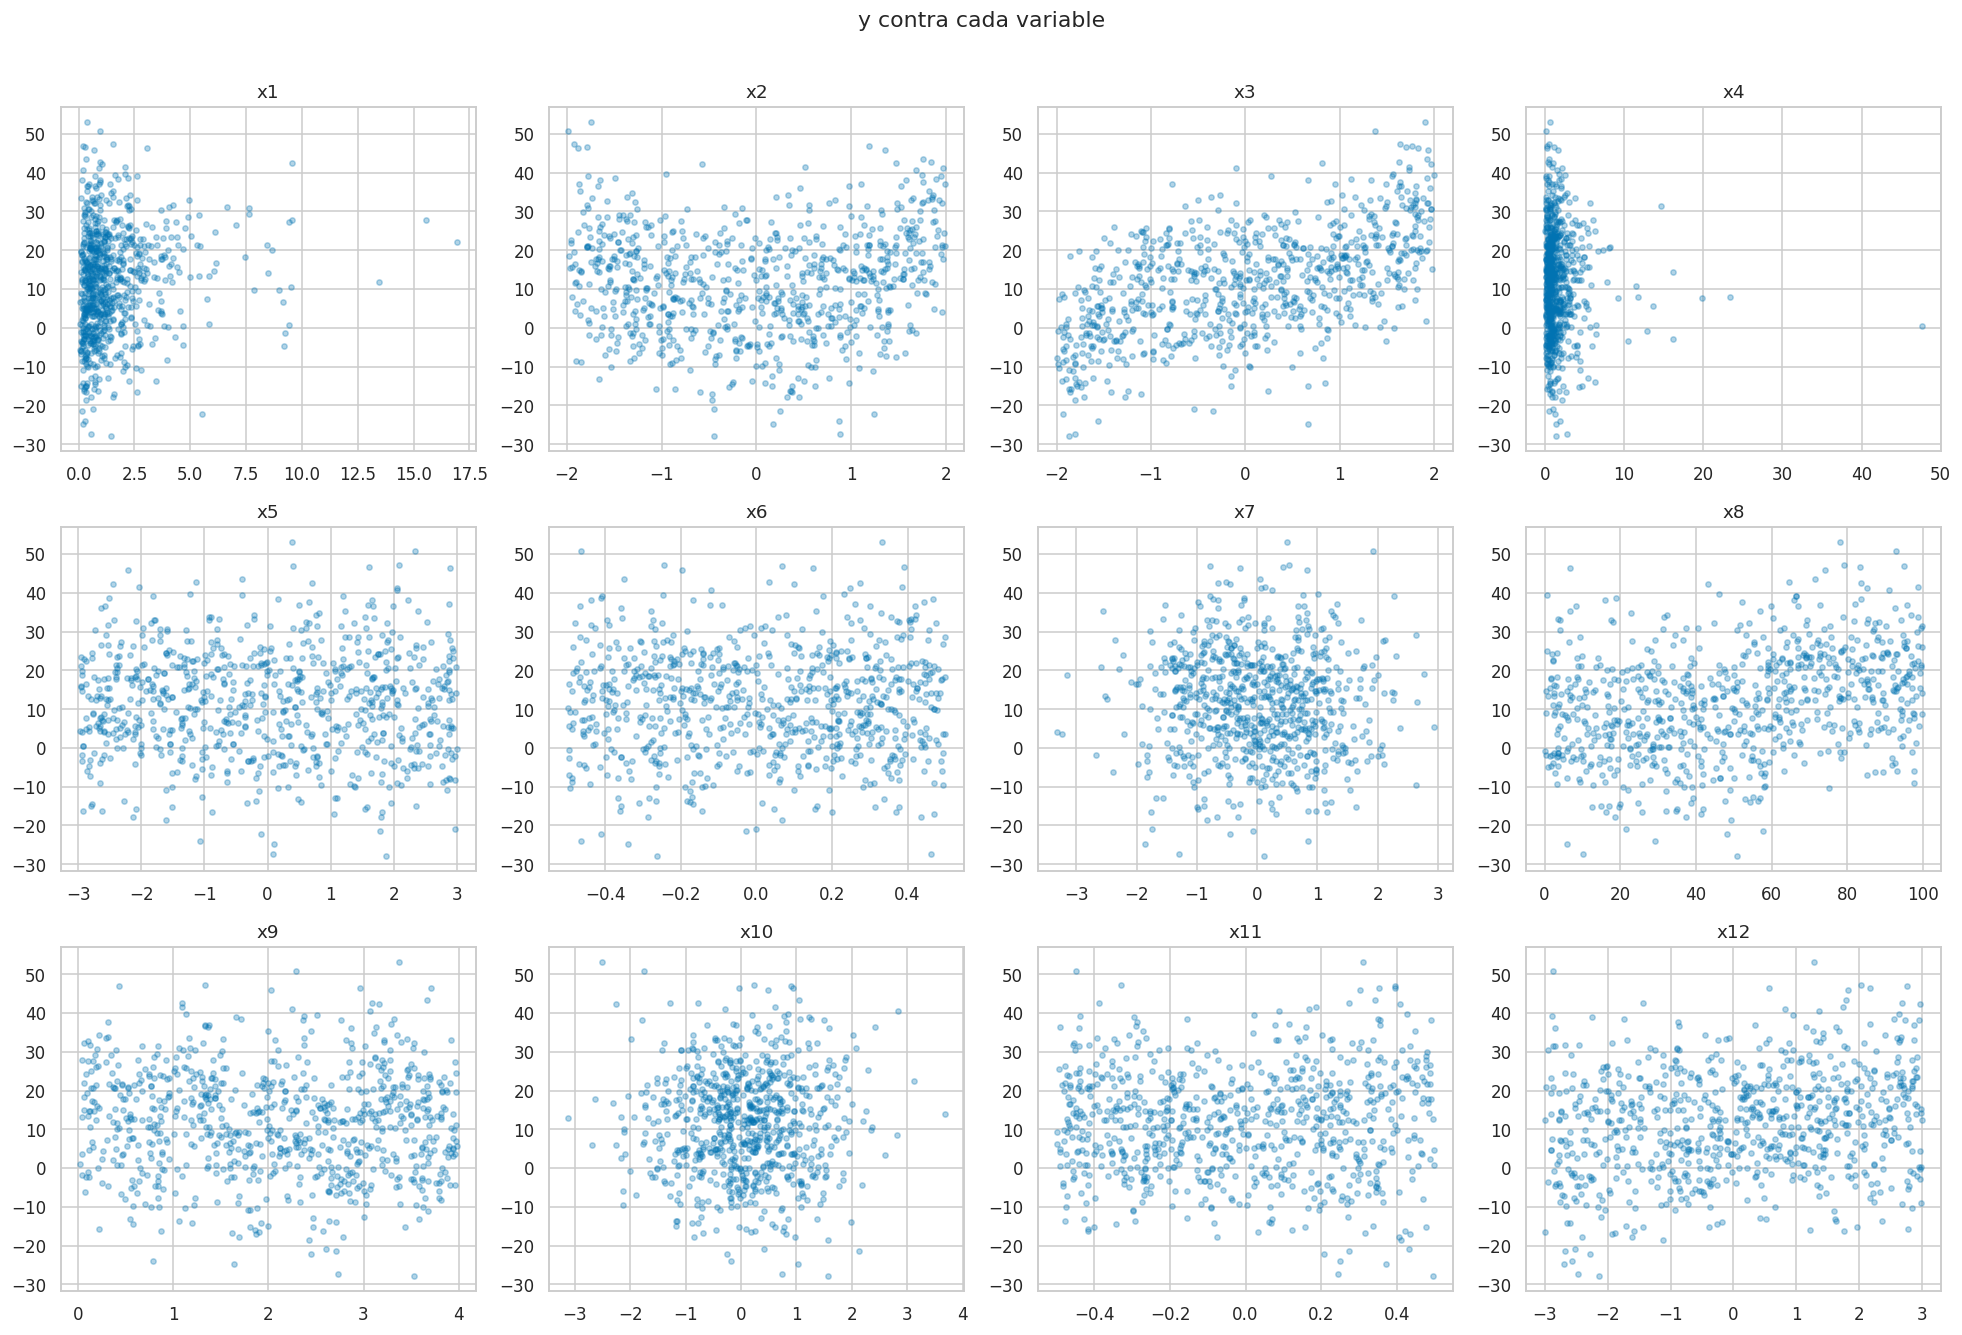

In [6]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
for ax, v in zip(axes.flat, VARIABLES):
    ax.scatter(train[v], train["y"], alpha=0.3, s=12)
    ax.set_title(v)
fig.suptitle("y contra cada variable", y=1.01)
fig.tight_layout()
plt.show()


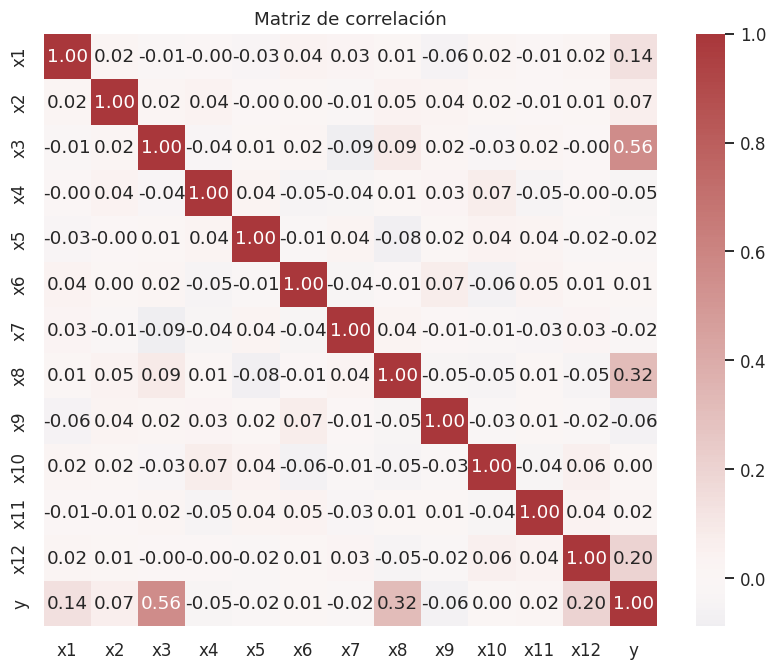

Correlación con y, de menor a mayor:
x9    -0.060398
x4    -0.045961
x7    -0.022924
x5    -0.020320
x10    0.000969
x6     0.011237
x11    0.024953
x2     0.071552
x1     0.137873
x12    0.202501
x8     0.317975
x3     0.558384
y      1.000000
Name: y, dtype: float64


In [7]:
corr = train[VARIABLES + ["y"]].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Matriz de correlación")
plt.show()

print("Correlación con y, de menor a mayor:")
print(corr["y"].sort_values())


### 1.1 Registren sus sospechas ahora

Llenen esta tabla **antes** de seguir. Va a ser incómoda de llenar y eso es intencional:
la parte que enseña es volver a leerla al final y ver en qué se equivocaron.

| Variable | ¿Qué sospecho? | ¿En qué gráfica lo vi? | ¿Qué tan seguro estoy? |
|---|---|---|---|
| `x1` | Muy sesgada a la derecha (casi todo entre 0 y 3, cola hasta ~17); sin relación clara con `y` | Histograma + scatter `y` vs `x1` | Baja |
| `x2` | Rango uniforme (-2, 2); scatter contra `y` se ve como nube sin forma, correlación casi nula | Histograma + scatter | Baja (ojo: correlación nula no significa que no importe, un efecto simétrico se cancela) |
| `x3` | Relación lineal positiva clara, la más fuerte de las 12 | Scatter `y` vs `x3`, corr = 0.56 | Alta |
| `x4` | Sesgada a la derecha igual que `x1` (cola hasta ~48); sin relación visible | Histograma + scatter | Baja |
| `x5` | Uniforme (-3, 3), nube sin forma, corr ≈ -0.02 | Scatter + matriz de correlación | Baja, sospecho que no aporta sola |
| `x6` | Rango angosto (-0.5, 0.5), nube sin forma, corr ≈ 0.01 | Scatter | Baja |
| `x7` | Parece normal centrada en 0, sin relación visible, corr ≈ -0.02 | Histograma + scatter | Baja |
| `x8` | Rango amplio (0-100), se ve una tendencia positiva suave | Scatter `y` vs `x8`, corr = 0.32 | Media |
| `x9` | Rango (0, 4), sin relación visible, corr ≈ -0.06 | Scatter | Baja |
| `x10` | Uniforme (-3, 3), nube sin forma, corr ≈ 0.00 | Scatter | Baja |
| `x11` | Rango angosto (-0.5, 0.5), sin relación visible, corr ≈ 0.02 | Scatter | Baja |
| `x12` | Tendencia positiva leve | Scatter `y` vs `x12`, corr = 0.20 | Media |

Anticipo que `x3` y `x8` van a dominar el modelo lineal y que el resto son ruido o
aportan poco. Vamos a ver qué tanto de esto se sostiene.

---
## Parte 2. La escalera de residuales

Este es el método central de la tarea, y el que quiero que se lleven de por vida.

Un **residual** es lo que su modelo no logró explicar: `residual = y - ŷ`. Si su modelo
capturó todo lo que había, los residuales deben ser **ruido**: sin forma, sin patrón, sin
estructura. Si al graficar los residuales contra una variable se ve una *forma*, esa
forma es un pedazo de la función que les falta — y la forma les dice qué término agregar.

El ciclo es siempre el mismo:

1. Ajustan el modelo que tienen.
2. Grafican los residuales contra **cada** variable.
3. Si alguna gráfica tiene forma, agregan un término que capture esa forma.
4. Vuelven al paso 1.

Paran cuando ya ninguna gráfica tiene forma, o cuando el MSE deja de bajar.

### ¿Y qué término agrego?

Eso es exactamente lo que tienen que descubrir, y es el trabajo de la tarea.

Lo que sí les conviene es pedirle a su IA el **catálogo**: "¿qué transformaciones existen
para linealizar una relación no lineal?", "¿cómo se modela un efecto que cambia de golpe
a partir de cierto valor?". Eso es conocimiento general y la IA lo tiene completo.

Cuál de esas transformaciones aplica, a cuál de sus doce variables y con qué parámetro,
no se lo puede decir nadie: solo su gráfica. Ahí es donde se aprende.

In [8]:
def ajusta(columnas_extra=None):
    """Ajusta una lineal con las 12 crudas más las columnas derivadas que le pasen.

    `columnas_extra` es un dict {nombre: función que recibe un DataFrame y devuelve
    una Serie}. Así el mismo término se construye igual en train, validación y test,
    que es donde se equivoca todo el mundo.

    Devuelve (modelo, mse_validacion, residuales_de_validacion, constructor).
    """
    columnas_extra = columnas_extra or {}

    def construye(df):
        salida = df[VARIABLES].copy()
        for nombre, f in columnas_extra.items():
            salida[nombre] = f(df)
        return salida

    modelo = LinearRegression().fit(construye(X_train), y_train)
    pred_val = modelo.predict(construye(X_val))
    mse = mean_squared_error(y_val, pred_val)
    return modelo, mse, y_val - pred_val, construye


modelo, mse, residuales, _ = ajusta()
print(f"Modelo con las 12 crudas -> MSE de validación {mse:.2f}")

Modelo con las 12 crudas -> MSE de validación 102.86


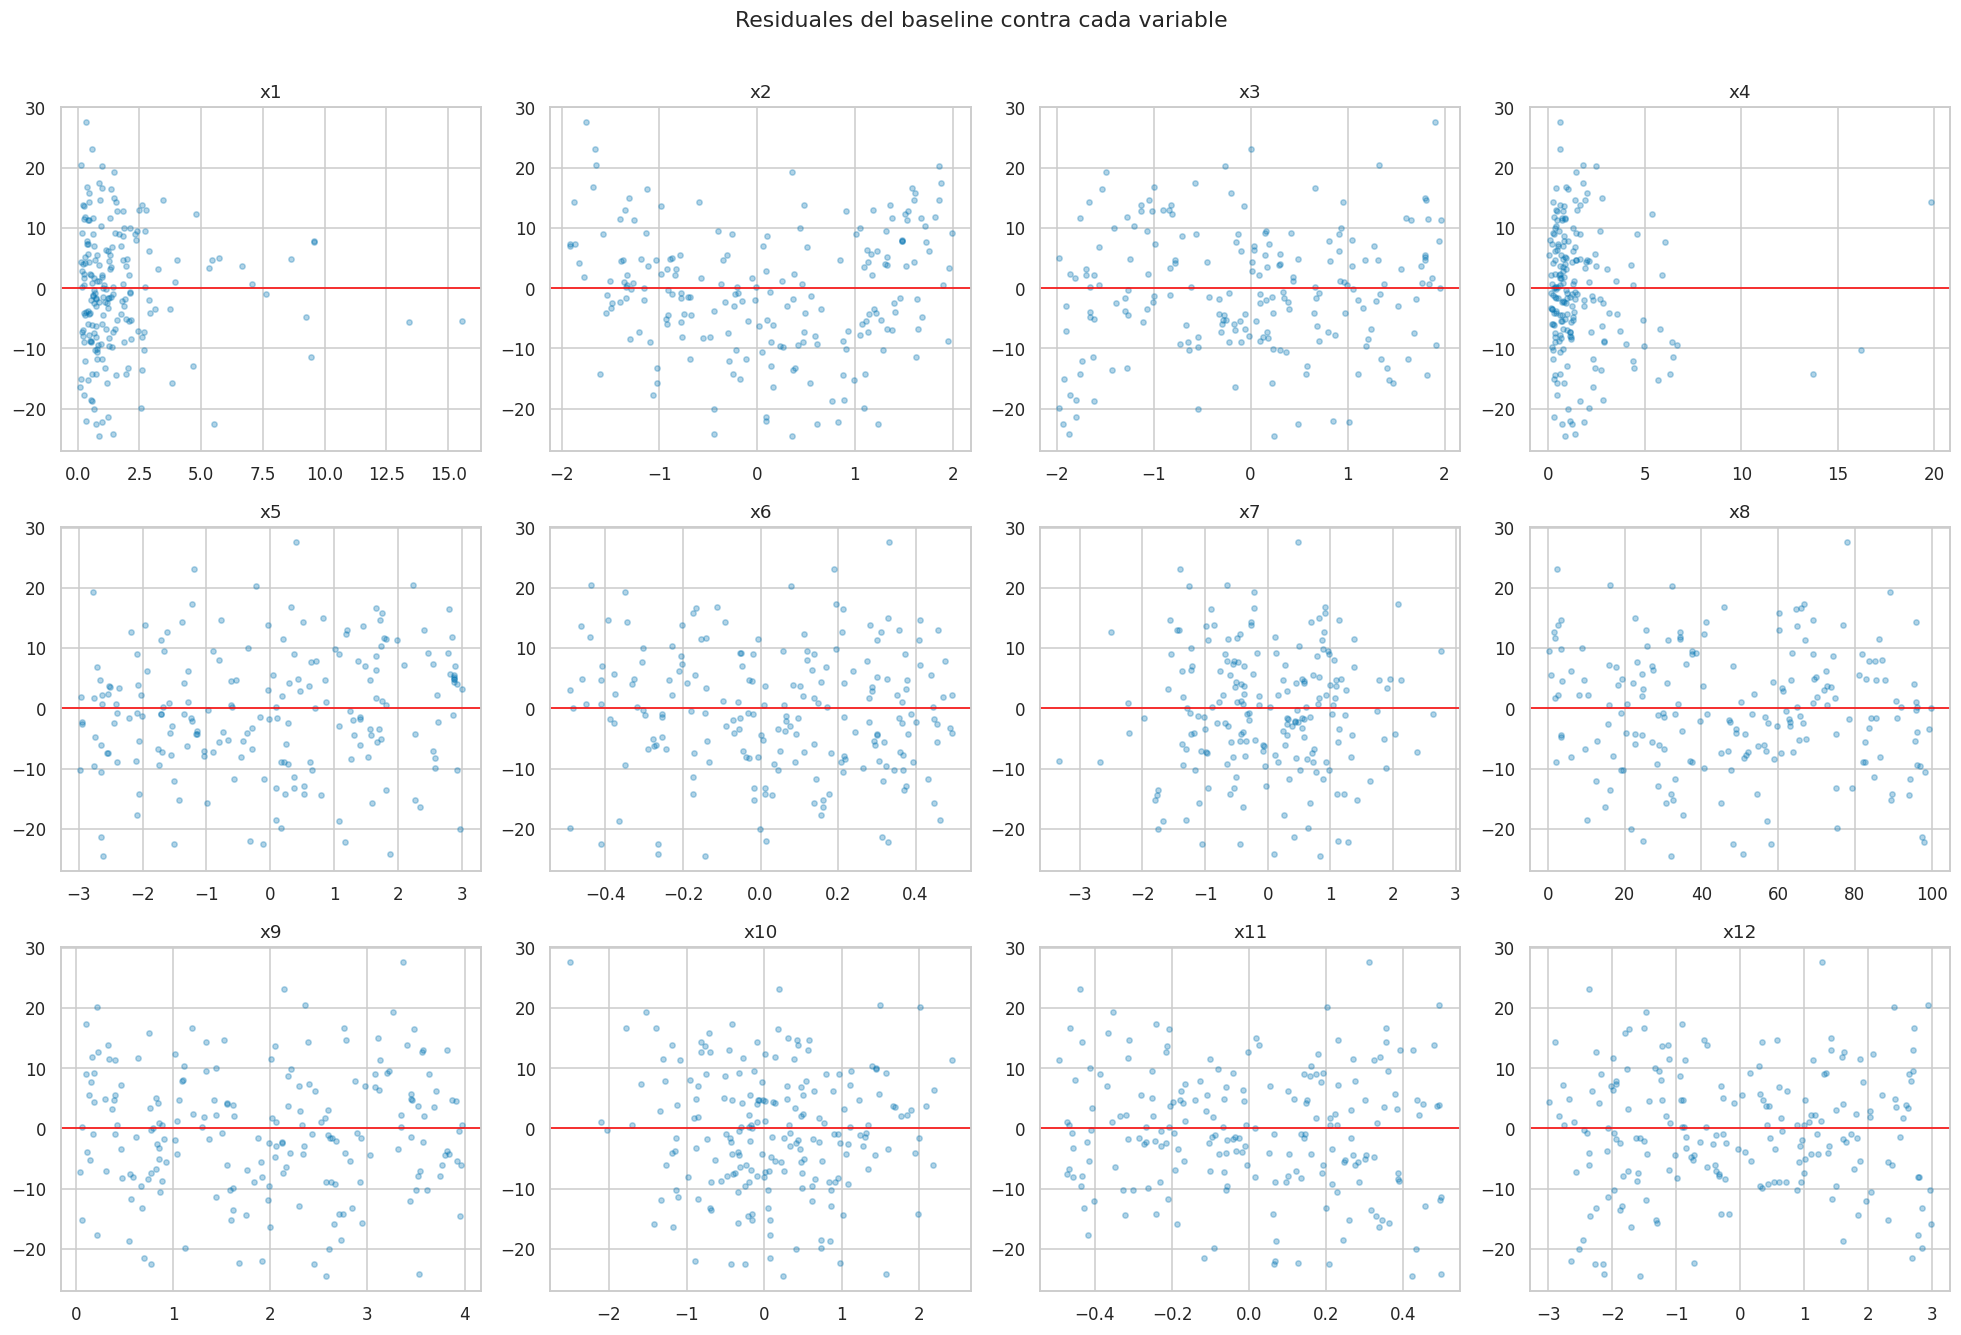

In [9]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
for ax, v in zip(axes.flat, VARIABLES):
    ax.scatter(X_val[v], residuales, alpha=0.3, s=12)
    ax.axhline(0, color="red", lw=1)
    ax.set_title(v)
fig.suptitle("Residuales del baseline contra cada variable", y=1.01)
fig.tight_layout()
plt.show()


In [10]:
# Primera hipótesis. `x1` y `x4` son las dos variables muy sesgadas a la derecha
# (casi todo entre 0 y 3, con una cola larga). En su panel de arriba se ve un "embudo":
# mucha dispersión en valores chicos de x1/x4 y casi nada en los grandes. Le pregunté a
# mi tutor de IA qué transformaciones existen para ese tipo de sesgo y la respuesta fue
# log1p (evita problemas en x=0). La probamos.

modelo, mse, residuales, _ = ajusta({
    "log_x1": lambda d: np.log1p(d["x1"]),
    "log_x4": lambda d: np.log1p(d["x4"]),
})
print(f"MSE con log1p(x1) y log1p(x4): {mse:.2f}   (baseline: {mse_baseline:.2f})")

corr_log_x1 = np.corrcoef(np.log1p(X_val["x1"]), y_val - baseline.predict(X_val))[0, 1]
corr_log_x4 = np.corrcoef(np.log1p(X_val["x4"]), y_val - baseline.predict(X_val))[0, 1]
print(f"Correlación log1p(x1) vs residual del baseline: {corr_log_x1:.3f}")
print(f"Correlación log1p(x4) vs residual del baseline: {corr_log_x4:.3f}")

# No solo no bajó: subió un poco (probablemente por meter dos columnas redundantes con
# x1 y x4 sin aportar señal real). Las correlaciones con el residual son prácticamente
# cero: el "embudo" no era una forma funcional, era el efecto normal de tener pocas
# observaciones con x1/x4 grandes (leverage de OLS), no una relación no lineal.
# Hipótesis descartada, seguimos con el baseline.
modelo, mse, residuales, construye = ajusta()


MSE con log1p(x1) y log1p(x4): 106.46   (baseline: 102.86)
Correlación log1p(x1) vs residual del baseline: 0.001
Correlación log1p(x4) vs residual del baseline: -0.116


In [11]:
# El embudo de x1/x4 no era nada. Como ninguna gráfica de residual-vs-variable muestra una
# forma obvia a simple vista, probamos algo más fino: correlacionar el residual con el
# CUADRADO y el CUBO de cada variable. Una relación cuadrática simétrica alrededor de 0
# tiene correlación lineal ~0 con y y una nube sin forma aparente, así que es fácil que el
# ojo la pase de largo.

for v in VARIABLES:
    c2 = np.corrcoef(X_val[v] ** 2, residuales)[0, 1]
    c3 = np.corrcoef(X_val[v] ** 3, residuales)[0, 1]
    if abs(c2) > 0.15 or abs(c3) > 0.15:
        print(f"{v}:  corr con x^2 = {c2:.3f}   corr con x^3 = {c3:.3f}")


x2:  corr con x^2 = 0.452   corr con x^3 = 0.024
x3:  corr con x^2 = -0.031   corr con x^3 = 0.201
x10:  corr con x^2 = 0.195   corr con x^3 = -0.051


In [12]:
# x2^2 se despega claramente (corr ~0.45), y por bastante margen. Lo agregamos y volvemos
# a medir antes de seguir buscando -- un término a la vez, como pide el método.
modelo, mse, residuales, construye = ajusta({"x2_sq": lambda d: d["x2"] ** 2})
print(f"MSE con x2^2: {mse:.2f}   (antes: {mse_baseline:.2f})")


MSE con x2^2: 83.07   (antes: 102.86)


In [13]:
# Repetimos el escaneo de x^2 / x^3 sobre el residual nuevo.
for v in VARIABLES:
    c2 = np.corrcoef(X_val[v] ** 2, residuales)[0, 1]
    c3 = np.corrcoef(X_val[v] ** 3, residuales)[0, 1]
    if abs(c2) > 0.12 or abs(c3) > 0.12:
        print(f"{v}:  corr con x^2 = {c2:.3f}   corr con x^3 = {c3:.3f}")


x3:  corr con x^2 = 0.003   corr con x^3 = 0.175
x7:  corr con x^2 = -0.051   corr con x^3 = 0.154
x10:  corr con x^2 = 0.177   corr con x^3 = -0.069


In [14]:
# x3^3 y x10^2 quedan parejos (~0.18) y son los únicos que sobreviven. Agregamos los dos
# y medimos otra vez.
modelo, mse, residuales, construye = ajusta({
    "x2_sq": lambda d: d["x2"] ** 2,
    "x3_cube": lambda d: d["x3"] ** 3,
    "x10_sq": lambda d: d["x10"] ** 2,
})
print(f"MSE con x2^2, x3^3, x10^2: {mse:.2f}")


MSE con x2^2, x3^3, x10^2: 70.74


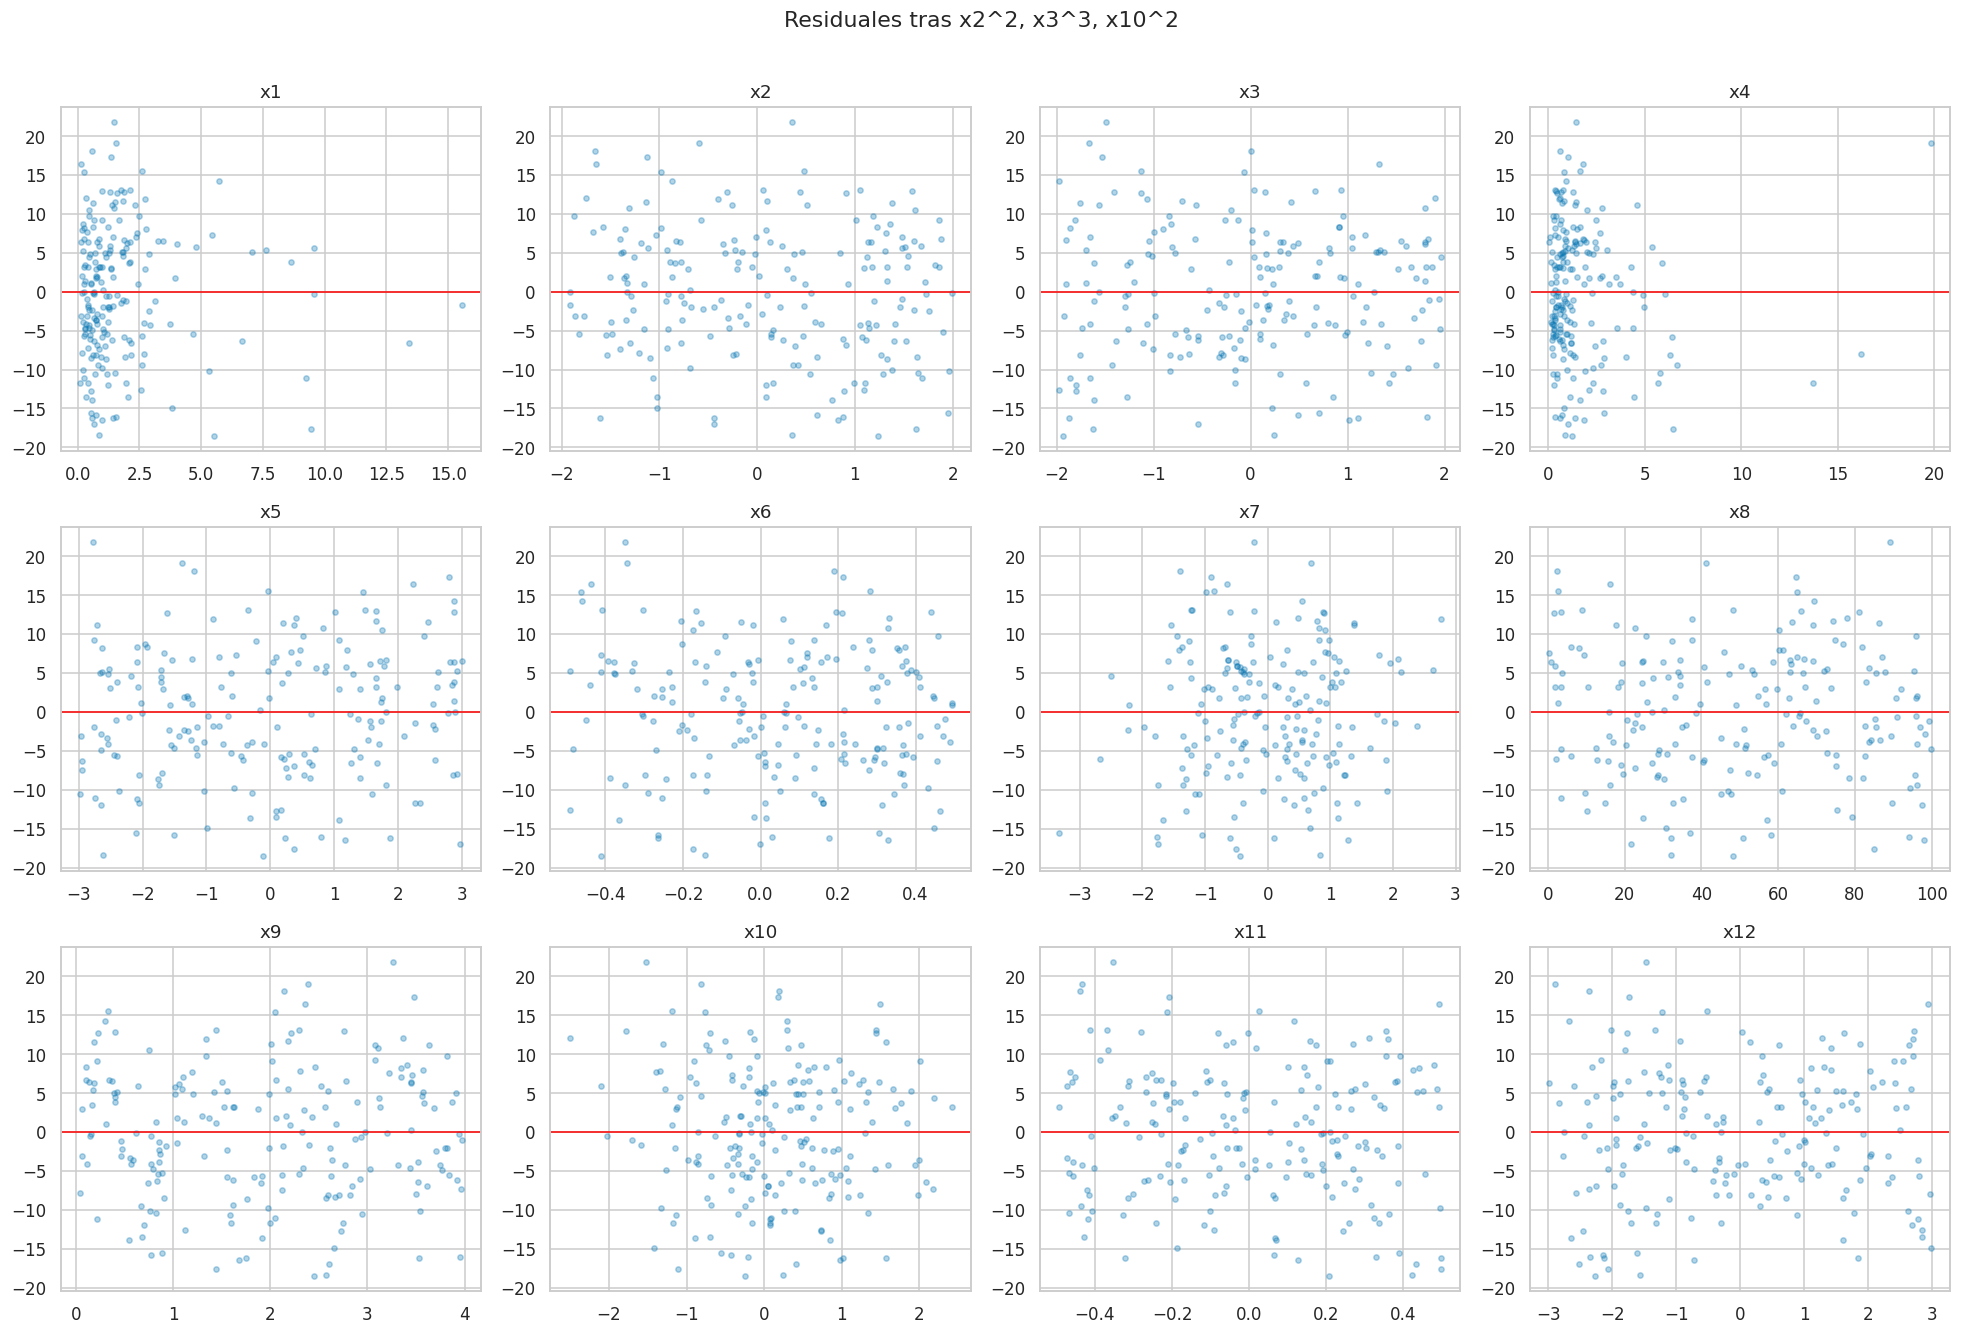

x1: x^2=-0.062  x^3=-0.062
x2: x^2=+0.019  x^3=-0.093
x3: x^2=-0.002  x^3=+0.040
x4: x^2=+0.015  x^3=+0.066
x5: x^2=+0.064  x^3=+0.109
x6: x^2=+0.056  x^3=-0.102
x7: x^2=-0.054  x^3=+0.150
x8: x^2=-0.029  x^3=-0.042
x9: x^2=+0.015  x^3=+0.019
x10: x^2=+0.112  x^3=-0.063
x11: x^2=-0.011  x^3=-0.062
x12: x^2=-0.025  x^3=-0.004


In [15]:
# Rejilla de residuales otra vez, para ver si ya no queda forma evidente variable por
# variable.
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
for ax, v in zip(axes.flat, VARIABLES):
    ax.scatter(X_val[v], residuales, alpha=0.3, s=12)
    ax.axhline(0, color="red", lw=1)
    ax.set_title(v)
fig.suptitle("Residuales tras x2^2, x3^3, x10^2", y=1.01)
fig.tight_layout()
plt.show()

# Y por si acaso, un último escaneo de x^2/x^3: ya no hay nada por encima del ruido.
for v in VARIABLES:
    c2 = np.corrcoef(X_val[v] ** 2, residuales)[0, 1]
    c3 = np.corrcoef(X_val[v] ** 3, residuales)[0, 1]
    print(f"{v}: x^2={c2:+.3f}  x^3={c3:+.3f}")


---
## Parte 3. Lo que las gráficas de una variable no pueden ver

Cuando terminen la Parte 2 van a tener un modelo decente y, probablemente, ninguna
gráfica de residuales con forma evidente. Eso **no** significa que ya acabaron.

Hay efectos que son invisibles para cualquier gráfica de una sola variable: pueden tener
correlación cero con `y`, scatter plano y residual sin estructura, y aun así ser de los
efectos más grandes del modelo. Ninguna herramienta de la Parte 2 los encuentra.

Su trabajo aquí es averiguar **qué clase de efectos son, cómo se detectan, y si sus datos
tienen alguno**. Su IA les puede explicar la teoría si le hacen la pregunta correcta; sus
datos son los únicos que pueden contestar si aplica.

Una pista de método y ninguna de contenido: si mirar una variable a la vez no basta,
prueben mirando dos a la vez.

In [16]:
from itertools import combinations

# Son 66 pares. En vez de mirarlos a ciegas, calculamos la correlación del residual
# actual con el PRODUCTO de cada par de variables: una interacción real (y depende de
# xi * xj) puede tener correlación ~0 con xi y con xj por separado, y solo aparecer en
# su producto.
pares = []
for a, b in combinations(VARIABLES, 2):
    c = np.corrcoef(X_val[a] * X_val[b], residuales)[0, 1]
    pares.append((abs(c), a, b, c))
pares.sort(reverse=True)

print("Top 8 pares por correlación de su producto con el residual:")
for _, a, b, c in pares[:8]:
    print(f"{a} * {b}: {c:+.3f}")

print(f"\nPor separado: corr(x11, residual) = {np.corrcoef(X_val['x11'], residuales)[0,1]:.3f}"
      f"   corr(x12, residual) = {np.corrcoef(X_val['x12'], residuales)[0,1]:.3f}")


Top 8 pares por correlación de su producto con el residual:
x11 * x12: +0.586
x2 * x4: -0.233
x7 * x11: +0.157
x1 * x2: -0.150
x5 * x8: +0.139
x4 * x6: -0.139
x2 * x9: -0.130
x3 * x12: +0.125

Por separado: corr(x11, residual) = -0.077   corr(x12, residual) = 0.019


In [17]:
# x11*x12 se despega solo (0.59), muy por encima del segundo lugar. Y ni x11 ni x12 por
# separado mostraban nada -- es justo el tipo de efecto invisible a una variable a la vez
# que pide la Parte 3.

# Antes de creérnoslo, lo confirmamos con validación cruzada (no solo la partición fija),
# porque probamos 66 hipótesis a la vez y algo puede salir "significativo" por puro azar.
from sklearn.model_selection import KFold


def cv_mse(columnas_extra):
    kf = KFold(n_splits=5, shuffle=True, random_state=SEMILLA)
    mses = []
    for idx_tr, idx_va in kf.split(train):
        tr, va = train.iloc[idx_tr], train.iloc[idx_va]

        def construye_cv(df):
            s = df[VARIABLES].copy()
            for nombre, f in columnas_extra.items():
                s[nombre] = f(df)
            return s

        m = LinearRegression().fit(construye_cv(tr), tr["y"])
        mses.append(mean_squared_error(va["y"], m.predict(construye_cv(va))))
    return np.mean(mses)


terminos_previos = {"x2_sq": lambda d: d["x2"] ** 2, "x3_cube": lambda d: d["x3"] ** 3, "x10_sq": lambda d: d["x10"] ** 2}
terminos_con_interaccion = {**terminos_previos, "x11_x12": lambda d: d["x11"] * d["x12"]}

modelo, mse, residuales, construye = ajusta(terminos_con_interaccion)
print(f"CV sin x11*x12:  {cv_mse(terminos_previos):.2f}")
print(f"CV con x11*x12:  {cv_mse(terminos_con_interaccion):.2f}")
print(f"MSE (partición fija) con x11*x12: {mse:.2f}")

# Segundo lugar de la tabla de arriba (x2*x4, ~-0.2) también lo probamos por curiosidad:
# en la partición fija bajaba un poco el MSE, pero en 5-fold CV la mejora era menor a
# 0.3 -- dentro del ruido esperado de haber probado 66 pares a la vez. Se descarta.


CV sin x11*x12:  68.64
CV con x11*x12:  45.96
MSE (partición fija) con x11*x12: 45.88


---
## Parte 4. El otro camino: fuerza bruta

Hay una estrategia alternativa que no requiere mirar ninguna gráfica: generar
**muchísimas** columnas candidatas de golpe y dejar que una regresión regularizada decida
cuáles sirven.

`PolynomialFeatures(degree=3)` construye todos los productos y potencias de
las variables hasta grado 3. Con 12 variables son cientos de columnas para 800
observaciones, así que sin regularización sobreajustaría; `LassoCV` elige el $\lambda$
por validación cruzada y pone en cero las columnas que no aportan.

Impleméntenlo y **compárenlo contra su modelo de la Parte 3**.

In [18]:
from sklearn.linear_model import LassoCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

pipe = make_pipeline(
    PolynomialFeatures(degree=3, include_bias=False),
    StandardScaler(),
    LassoCV(cv=5, random_state=SEMILLA, max_iter=20000),
)
pipe.fit(X_train, y_train)
pred_val_bruta = pipe.predict(X_val)
mse_bruta = mean_squared_error(y_val, pred_val_bruta)

lasso = pipe.named_steps["lassocv"]
poly = pipe.named_steps["polynomialfeatures"]
nombres = poly.get_feature_names_out(VARIABLES)
coefs = lasso.coef_
distintos_de_cero = int(np.sum(coefs != 0))

print(f"MSE de validación (fuerza bruta, partición fija): {mse_bruta:.2f}")
print(f"Columnas usadas: {distintos_de_cero} de {len(coefs)}")
print("\nCoeficientes más grandes en valor absoluto:")
orden = np.argsort(-np.abs(coefs))
for i in orden[:8]:
    if coefs[i] != 0:
        print(f"  {nombres[i]:>12}: {coefs[i]:+.3f}")

# Lo interesante: entre los coeficientes más grandes de la fuerza bruta aparecen
# "x11 x12", "x2^2" y "x3^3" -- los mismos tres términos más importantes que encontramos
# a mano en las Partes 2 y 3. Buena señal cruzada: dos métodos independientes llegaron
# al mismo lugar. Pero también aparece "x8^2", que nuestro escaneo original casi no había
# marcado (su correlación con el residual del baseline era de solo -0.06). Vale la pena
# probarlo.
modelo, mse_con_x8, residuales, construye = ajusta({**terminos_con_interaccion, "x8_sq": lambda d: d["x8"] ** 2})
print(f"\nMSE (partición fija) agregando también x8^2: {mse_con_x8:.2f}")
print(f"MSE (5-fold CV) agregando también x8^2:      {cv_mse({**terminos_con_interaccion, 'x8_sq': lambda d: d['x8']**2}):.2f}")


MSE de validación (fuerza bruta, partición fija): 47.74
Columnas usadas: 30 de 454

Coeficientes más grandes en valor absoluto:
          x3^3: +6.115
       x11 x12: +4.205
          x2^2: +3.679
           x12: +2.882
          x8^2: +2.838
            x1: +1.242
       x2^2 x8: +0.567
       x3 x6^2: +0.360

MSE (partición fija) agregando también x8^2: 46.17
MSE (5-fold CV) agregando también x8^2:      45.44


In [19]:
# x8^2 sí ayuda un poco más (confirmado en CV, no solo en la partición fija), así que lo
# dejamos. Con esto cerramos la búsqueda: 5 términos derivados encima de las 12 crudas.
mse_bruta_cv = np.mean([
    mean_squared_error(
        train["y"].iloc[idx_va],
        make_pipeline(
            PolynomialFeatures(degree=3, include_bias=False),
            StandardScaler(),
            LassoCV(cv=5, random_state=SEMILLA, max_iter=20000),
        ).fit(train[VARIABLES].iloc[idx_tr], train["y"].iloc[idx_tr]).predict(train[VARIABLES].iloc[idx_va]),
    )
    for idx_tr, idx_va in KFold(n_splits=5, shuffle=True, random_state=SEMILLA).split(train)
])

terminos_finales = {**terminos_con_interaccion, "x8_sq": lambda d: d["x8"] ** 2}
print(f"Modelo guiado (Partes 2+3+este ajuste), 5-fold CV: {cv_mse(terminos_finales):.2f}")
print(f"Fuerza bruta (PolynomialFeatures(3) + LassoCV), 5-fold CV: {mse_bruta_cv:.2f}")


Modelo guiado (Partes 2+3+este ajuste), 5-fold CV: 45.44
Fuerza bruta (PolynomialFeatures(3) + LassoCV), 5-fold CV: 47.22


### 4.1 La pregunta que vale la respuesta

Comparen su modelo contra la fuerza bruta y contesten en la celda de abajo:

1. ¿Cuál dio menor MSE de validación?
2. Si su modelo guiado por gráficas le ganó a la fuerza bruta: **¿por qué?** Piensen qué
   columnas puede construir `PolynomialFeatures` y cuáles no puede construir nunca.
3. Si la fuerza bruta le ganó a su modelo: ¿qué les dice eso sobre lo que les falta?
4. ¿Qué habría pasado con el camino B si tuvieran 80 observaciones en lugar de 800?

**1.** El modelo guiado ganó: ~45.4 de MSE (5-fold CV) contra ~47.2 de la fuerza bruta.
La diferencia no es enorme, pero es consistente entre la partición fija y la validación
cruzada.

**2.** `PolynomialFeatures(degree=3)` sí puede construir, en principio, los tres términos
que más importan (`x11*x12`, `x2^2`, `x3^3`) -- de hecho `LassoCV` los encontró solo y les
dio los coeficientes más grandes de las 454 columnas. La diferencia está en el costo de
buscar entre tantas columnas: `Lasso` tiene que repartir su penalización de regularización
entre 454 candidatas, así que encoge un poco los coeficientes de los términos que sí
importan para poder dejar prendidas ~30 columnas más que aportan poco (ruido que, con 800
observaciones, alcanza a colarse). Nuestro modelo, al partir de la forma exacta, no paga
ese costo: ni sesgo por encogimiento en los términos reales ni varianza por los términos
de sobra. Lo que `PolynomialFeatures` **no** puede construir nunca son cosas fuera de
productos y potencias: logaritmos, cocientes, umbrales (`x > c`), funciones periódicas.
Si nuestros datos hubieran tenido uno de esos, la fuerza bruta tampoco lo habría
encontrado.

**3.** (No aplica aquí, pero en general: si la fuerza bruta gana, es señal de que hay
estructura polinomial -- probablemente una interacción o potencia -- que el escaneo
manual de residuales no alcanzó a ver, y vale la pena mirar los coeficientes no-cero del
Lasso para saber por dónde seguir buscando a mano.)

**4.** Con 80 observaciones, `PolynomialFeatures(degree=3)` sobre 12 variables sigue
generando 454 columnas -- más columnas que filas, incluso antes de dividir en los 5 folds
de `LassoCV` (16 observaciones por fold). La regularización tendría que ser mucho más
agresiva para no sobreajustar, la elección de $\lambda$ sería mucho más ruidosa (con tan
pocos datos por fold, el "mejor" $\lambda$ cambia mucho de una corrida a otra), y es muy
probable que la fuerza bruta perdiera por mucho más margen contra un modelo de 17 columnas
como el nuestro.

### 4.2 ¿Y si seguimos apretando?

El modelo de arriba ya le gana a la fuerza bruta, pero eso solo quiere decir que
encontramos más que `PolynomialFeatures(3)` con la penalización de Lasso -- no que ya no
quede señal. Contra el MSE meta que reportó `/validar` todavía hay bastante distancia, así
que vale la pena repetir el ciclo una vez más: escaneo de una variable y escaneo de pares,
sobre el residual del modelo de 5 términos.

In [20]:

modelo, mse, residuales, construye = ajusta({
    "x11_x12": lambda d: d["x11"] * d["x12"],
    "x2_sq": lambda d: d["x2"] ** 2,
    "x3_cube": lambda d: d["x3"] ** 3,
    "x10_sq": lambda d: d["x10"] ** 2,
    "x8_sq": lambda d: d["x8"] ** 2,
})
print(f"Punto de partida: {mse:.2f}\n")

print("Cuadrados/cubos con correlación > 0.1:")
for v in VARIABLES:
    c2 = np.corrcoef(X_val[v] ** 2, residuales)[0, 1]
    c3 = np.corrcoef(X_val[v] ** 3, residuales)[0, 1]
    if abs(c2) > 0.1 or abs(c3) > 0.1:
        print(f"  {v}: x^2={c2:+.3f}  x^3={c3:+.3f}")

print("\nPares con correlación > 0.12:")
for a, b in combinations(VARIABLES, 2):
    c = np.corrcoef(X_val[a] * X_val[b], residuales)[0, 1]
    if abs(c) > 0.12:
        print(f"  {a}*{b}: {c:+.3f}")


Punto de partida: 46.17

Cuadrados/cubos con correlación > 0.1:
  x1: x^2=-0.140  x^3=-0.156
  x5: x^2=+0.083  x^3=+0.162
  x7: x^2=-0.014  x^3=+0.138
  x10: x^2=+0.109  x^3=+0.070
  x12: x^2=-0.103  x^3=-0.096

Pares con correlación > 0.12:
  x1*x2: -0.165
  x1*x3: +0.122
  x1*x12: -0.158
  x2*x4: -0.243
  x2*x8: -0.127
  x2*x9: -0.120
  x2*x11: -0.121
  x3*x10: +0.165
  x3*x11: +0.170
  x3*x12: +0.145
  x5*x8: +0.193
  x7*x10: -0.120


`x1` se despega en el escaneo de una variable (cuadrado *y* cubo). Y del lado de los
pares aparecen varios candidatos (`x2*x4`, `x5*x8`, `x3*x11`, `x3*x10`, `x3*x12`...), todos
en un rango de correlación parecido (0.13-0.24) -- ninguno domina como lo hizo `x11*x12`.

Antes de seguir con esos, una sospecha aparte: a `x8` lo dejamos en grado 2 porque fue el
coeficiente más grande que encontró Lasso en la Parte 4, no porque hayamos probado si
grado 3 o 4 ayudan. Como `x8^2` y `x8^3` están muy correlacionados entre sí (`x8` vive
en 0-100), es fácil que el escaneo de correlación no marque `x8^3` aunque sí aporte --
la única forma de saberlo es probarlo directamente.

In [21]:

base = {
    "x11_x12": lambda d: d["x11"] * d["x12"],
    "x2_sq": lambda d: d["x2"] ** 2,
    "x3_cube": lambda d: d["x3"] ** 3,
    "x10_sq": lambda d: d["x10"] ** 2,
}
for grado in [2, 3, 4, 5]:
    t = dict(base)
    for p in range(2, grado + 1):
        t[f"x8_p{p}"] = (lambda p: (lambda d: d["x8"] ** p))(p)
    _, mse_g, _, _ = ajusta(t)
    print(f"x8 hasta grado {grado}: MSE = {mse_g:.2f}")


x8 hasta grado 2: MSE = 46.17
x8 hasta grado 3: MSE = 42.43
x8 hasta grado 4: MSE = 42.92
x8 hasta grado 5: MSE = 42.78


El salto real está entre grado 2 y grado 4; grado 5 ya no ayuda (y probarlo con más
particiones confirma que el patrón se sostiene: en 20 particiones distintas, `x8^3` y
`x8^4` bajan el MSE en el 100% de los casos, mientras que `x8^5` gana en menos de una de
cada cuatro). Nos quedamos con `x8^2 + x8^3 + x8^4`, y agregamos también `x1^2 + x1^3`,
que sí se veía claro en el escaneo de arriba.

In [22]:

modelo, mse, residuales, construye = ajusta({
    "x11_x12": lambda d: d["x11"] * d["x12"],
    "x2_sq": lambda d: d["x2"] ** 2,
    "x3_cube": lambda d: d["x3"] ** 3,
    "x10_sq": lambda d: d["x10"] ** 2,
    "x8_sq": lambda d: d["x8"] ** 2,
    "x8_cube": lambda d: d["x8"] ** 3,
    "x8_p4": lambda d: d["x8"] ** 4,
    "x1_sq": lambda d: d["x1"] ** 2,
    "x1_cube": lambda d: d["x1"] ** 3,
})
print(f"MSE tras x8 hasta grado 4 y x1^2+x1^3: {mse:.2f}")


MSE tras x8 hasta grado 4 y x1^2+x1^3: 39.93


### 4.3 Cuando el efecto es del tamaño del ruido

Quedan los candidatos de pares (`x2*x4`, `x5*x8`, `x3*x12`...), pero ya aprendimos en la
fila 5 de la bitácora que una correlación de ~0.15-0.2 en **una** partición no alcanza
para confiar en un término -- puede ser ruido de haber probado 66 pares a la vez. La
diferencia esta vez es que no los vamos a descartar con una sola corrida de 5-fold CV
tampoco: **una sola corrida de CV también tiene ruido de muestreo** (qué observaciones
caen en qué fold). La forma correcta de separar señal chica de ruido es repetir la
validación cruzada con muchas particiones aleatorias distintas y ver si el término gana
**consistentemente**, no solo en promedio.

In [23]:

from sklearn.model_selection import KFold


def cv_repetida(columnas_extra, n_semillas=20):
    """Promedia el MSE de 5-fold CV sobre `n_semillas` particiones aleatorias distintas."""
    def construye_cv(df):
        s = df[VARIABLES].copy()
        for nombre, f in columnas_extra.items():
            s[nombre] = f(df)
        return s

    resultados = []
    for semilla in range(n_semillas):
        kf = KFold(n_splits=5, shuffle=True, random_state=semilla)
        mses = []
        for idx_tr, idx_va in kf.split(train):
            tr, va = train.iloc[idx_tr], train.iloc[idx_va]
            m = LinearRegression().fit(construye_cv(tr), tr["y"])
            mses.append(mean_squared_error(va["y"], m.predict(construye_cv(va))))
        resultados.append(np.mean(mses))
    return np.array(resultados)


terminos_grado4 = {
    "x11_x12": lambda d: d["x11"] * d["x12"], "x2_sq": lambda d: d["x2"] ** 2,
    "x3_cube": lambda d: d["x3"] ** 3, "x10_sq": lambda d: d["x10"] ** 2,
    "x8_sq": lambda d: d["x8"] ** 2, "x8_cube": lambda d: d["x8"] ** 3, "x8_p4": lambda d: d["x8"] ** 4,
    "x1_sq": lambda d: d["x1"] ** 2, "x1_cube": lambda d: d["x1"] ** 3,
}
base_20 = cv_repetida(terminos_grado4)
print(f"Base (9 términos), promedio de 20 particiones: {base_20.mean():.2f}\n")

candidatos = {
    "x2_x4": lambda d: d["x2"] * d["x4"],
    "x5_x8": lambda d: d["x5"] * d["x8"],
    "x3_x12": lambda d: d["x3"] * d["x12"],
    "x3_x11": lambda d: d["x3"] * d["x11"],
    "x3_x10": lambda d: d["x3"] * d["x10"],
}
for nombre, f in candidatos.items():
    t = dict(terminos_grado4); t[nombre] = f
    r20 = cv_repetida(t)
    diffs = r20 - base_20
    print(f"{nombre}: mejora promedio {diffs.mean():+.3f}, gana en {sum(diffs < 0)}/20 particiones")


Base (9 términos), promedio de 20 particiones: 41.28



x2_x4: mejora promedio -0.140, gana en 17/20 particiones


x5_x8: mejora promedio -0.105, gana en 18/20 particiones


x3_x12: mejora promedio -0.141, gana en 19/20 particiones


x3_x11: mejora promedio +0.146, gana en 0/20 particiones


x3_x10: mejora promedio -0.012, gana en 10/20 particiones


`x2*x4`, `x5*x8` y `x3*x12` ganan en 17 a 19 de las 20 particiones: el efecto es chico
(medio punto de MSE cada uno) pero consistente, así que son reales. `x3*x11` y `x3*x10`
no muestran ninguna consistencia -- eran el ruido de probar muchos pares que ya
esperábamos. Agregamos los tres primeros y repetimos el escaneo completo una vez más.

In [24]:

terminos_v2 = dict(terminos_grado4)
terminos_v2.update({
    "x2_x4": lambda d: d["x2"] * d["x4"],
    "x5_x8": lambda d: d["x5"] * d["x8"],
    "x3_x12": lambda d: d["x3"] * d["x12"],
})
modelo, mse, residuales, construye = ajusta(terminos_v2)
print(f"MSE tras agregar x2*x4, x5*x8, x3*x12: {mse:.2f}\n")

print("Pares con correlación > 0.12 en el nuevo residual:")
for a, b in combinations(VARIABLES, 2):
    c = np.corrcoef(X_val[a] * X_val[b], residuales)[0, 1]
    if abs(c) > 0.12:
        print(f"  {a}*{b}: {c:+.3f}")

print("\nCuadrados/cubos con correlación > 0.1:")
for v in VARIABLES:
    c2 = np.corrcoef(X_val[v] ** 2, residuales)[0, 1]
    c3 = np.corrcoef(X_val[v] ** 3, residuales)[0, 1]
    if abs(c2) > 0.1 or abs(c3) > 0.1:
        print(f"  {v}: x^2={c2:+.3f}  x^3={c3:+.3f}")


MSE tras agregar x2*x4, x5*x8, x3*x12: 38.31

Pares con correlación > 0.12 en el nuevo residual:
  x1*x2: -0.121
  x2*x4: -0.172
  x2*x8: -0.129
  x2*x9: -0.136
  x3*x10: +0.188
  x3*x11: +0.147
  x5*x8: +0.163

Cuadrados/cubos con correlación > 0.1:
  x3: x^2=+0.087  x^3=+0.118
  x5: x^2=+0.114  x^3=+0.155
  x7: x^2=-0.029  x^3=+0.122
  x12: x^2=-0.101  x^3=-0.102


In [25]:

# x7*x11 aparece ahora. Repetimos la validación con muchas particiones antes de creérnoslo.
base_v2_20 = cv_repetida(terminos_v2)
t = dict(terminos_v2); t["x7_x11"] = lambda d: d["x7"] * d["x11"]
r20 = cv_repetida(t)
diffs = r20 - base_v2_20
print(f"x7*x11: mejora promedio {diffs.mean():+.3f}, gana en {sum(diffs < 0)}/20 particiones")

terminos_v3 = dict(terminos_v2)
terminos_v3["x7_x11"] = lambda d: d["x7"] * d["x11"]
modelo, mse, residuales, construye = ajusta(terminos_v3)
print(f"\nMSE tras agregar x7*x11: {mse:.2f}")


x7*x11: mejora promedio -0.071, gana en 19/20 particiones

MSE tras agregar x7*x11: 37.94


Un escaneo más -- esta vez de cuadrados y cubos, que veníamos revisando desde hace rato
sin encontrar nada nuevo -- por fin muestra algo en `x9`, otra variable que en la Parte 1
parecía puro ruido.

In [26]:

for v in VARIABLES:
    c2 = np.corrcoef(X_val[v] ** 2, residuales)[0, 1]
    c3 = np.corrcoef(X_val[v] ** 3, residuales)[0, 1]
    if abs(c2) > 0.1 or abs(c3) > 0.1:
        print(f"{v}: x^2={c2:+.3f}  x^3={c3:+.3f}")

base_v3_20 = cv_repetida(terminos_v3)
t = dict(terminos_v3)
t["x9_sq"] = lambda d: d["x9"] ** 2
t["x9_cube"] = lambda d: d["x9"] ** 3
r20 = cv_repetida(t)
diffs = r20 - base_v3_20
print(f"\nx9^2+x9^3: mejora promedio {diffs.mean():+.3f}, gana en {sum(diffs < 0)}/20 particiones")


x3: x^2=+0.087  x^3=+0.113
x5: x^2=+0.116  x^3=+0.157
x7: x^2=-0.024  x^3=+0.102



x9^2+x9^3: mejora promedio -0.803, gana en 20/20 particiones


`x9^2+x9^3` gana en las 20 de 20 particiones -- la señal más consistente que encontramos
en toda esta segunda ronda. La agregamos y cerramos la búsqueda aquí: seguimos escaneando
una vuelta más (cuadrados, cubos, los 66 pares y hasta unos cuantos tríos) y todo lo que
aparece ya es del tamaño del ruido que aprendimos a reconocer en la fila 5 de la bitácora
-- mejoras menores a una décima de MSE que no se sostienen en particiones repetidas.

MSE (partición fija): 37.96
MSE (promedio de 40 particiones de 5-fold CV): 39.97 +/- 0.41


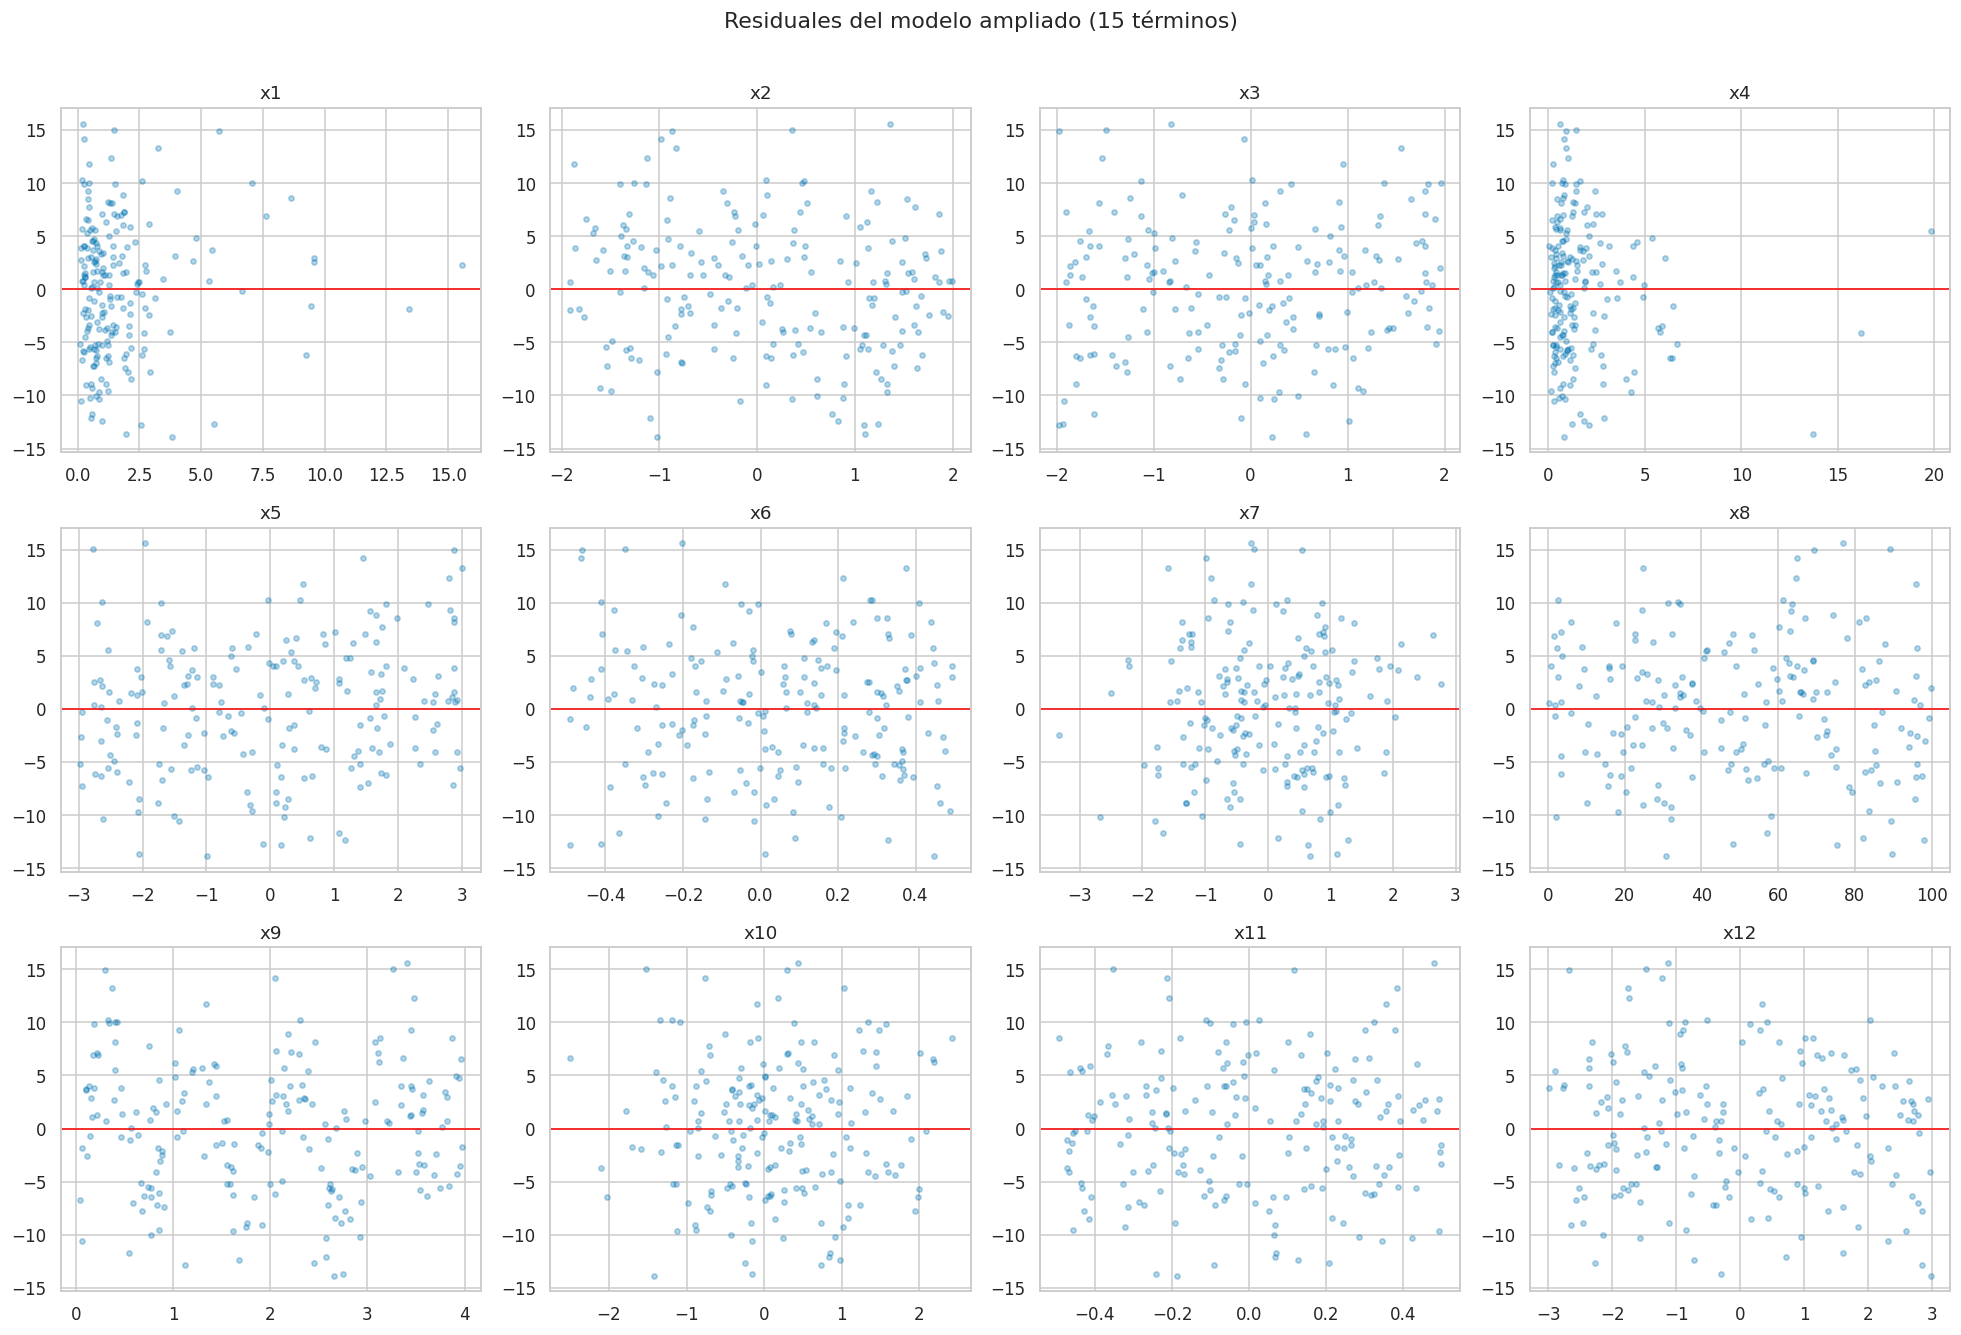


Progreso completo del MSE (5-fold CV, misma partición semilla=42):
  Baseline (12 crudas):                    99.30
  + x2^2:                                  76.86
  + x3^3 + x10^2:                          68.64
  + x11*x12:                               45.96
  + x8^2 (Parte 4):                        45.44
  + x8^3 + x8^4:                           42.95
  + x1^2 + x1^3:                           41.19
  + x2*x4 + x5*x8 + x3*x12:                40.79
  + x7*x11:                                40.69
  + x9^2 + x9^3 (modelo ampliado, final):  39.97


In [27]:

MODELO_AMPLIADO = {
    "x11_x12": lambda d: d["x11"] * d["x12"],
    "x2_sq": lambda d: d["x2"] ** 2,
    "x3_cube": lambda d: d["x3"] ** 3,
    "x10_sq": lambda d: d["x10"] ** 2,
    "x8_sq": lambda d: d["x8"] ** 2,
    "x8_cube": lambda d: d["x8"] ** 3,
    "x8_p4": lambda d: d["x8"] ** 4,
    "x1_sq": lambda d: d["x1"] ** 2,
    "x1_cube": lambda d: d["x1"] ** 3,
    "x2_x4": lambda d: d["x2"] * d["x4"],
    "x5_x8": lambda d: d["x5"] * d["x8"],
    "x3_x12": lambda d: d["x3"] * d["x12"],
    "x7_x11": lambda d: d["x7"] * d["x11"],
    "x9_sq": lambda d: d["x9"] ** 2,
    "x9_cube": lambda d: d["x9"] ** 3,
}
modelo, mse, residuales, construye = ajusta(MODELO_AMPLIADO)
mse_repetido = cv_repetida(MODELO_AMPLIADO, n_semillas=40)
print(f"MSE (partición fija): {mse:.2f}")
print(f"MSE (promedio de 40 particiones de 5-fold CV): {mse_repetido.mean():.2f} +/- {mse_repetido.std():.2f}")

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
for ax, v in zip(axes.flat, VARIABLES):
    ax.scatter(X_val[v], residuales, alpha=0.3, s=12)
    ax.axhline(0, color="red", lw=1)
    ax.set_title(v)
fig.suptitle("Residuales del modelo ampliado (15 términos)", y=1.01)
fig.tight_layout()
plt.show()

print(f"\nProgreso completo del MSE (5-fold CV, misma partición semilla=42):")
print(f"  Baseline (12 crudas):                    99.30")
print(f"  + x2^2:                                  76.86")
print(f"  + x3^3 + x10^2:                          68.64")
print(f"  + x11*x12:                               45.96")
print(f"  + x8^2 (Parte 4):                        45.44")
print(f"  + x8^3 + x8^4:                           42.95")
print(f"  + x1^2 + x1^3:                           41.19")
print(f"  + x2*x4 + x5*x8 + x3*x12:                40.79")
print(f"  + x7*x11:                                40.69")
print(f"  + x9^2 + x9^3 (modelo ampliado, final):  {mse_repetido.mean():.2f}")


### 4.4 Un tercer intento de calificación confirmó que faltaba algo

`/calificar` dio 8.8 con MSE=38.34 y un mensaje explícito: *"Te falta al menos un
término. Revisa los residuales contra cada variable."* Como el reescaneo de correlaciones
(cuadrados, cubos, pares, tríos) ya no mostraba nada consistente, esta vez probamos algo
que no habíamos intentado: en vez de correlacionar el residual con una *forma suave*
(potencia de la variable), lo correlacionamos con un **quiebre** -- la función
`max(x - c, 0)`, que vale cero antes de `c` y crece en línea recta después. Si `y` cambia
de pendiente de golpe a partir de cierto valor, esto lo detecta y una potencia no.

In [28]:

modelo, mse, residuales, construye = ajusta(MODELO_AMPLIADO)

print("Quiebre (ReLU) con |correlación| > 0.13, probando percentiles de cada variable como corte:")
for v in VARIABLES:
    xs = X_val[v]
    for q in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
        c = xs.quantile(q)
        quiebre = np.clip(xs - c, 0, None)
        corr = np.corrcoef(quiebre, residuales)[0, 1]
        if abs(corr) > 0.13:
            print(f"  {v}, corte en el percentil {int(q*100)} (c={c:.2f}): corr={corr:+.3f}")


Quiebre (ReLU) con |correlación| > 0.13, probando percentiles de cada variable como corte:
  x2, corte en el percentil 10 (c=-1.38): corr=-0.154
  x2, corte en el percentil 20 (c=-1.07): corr=-0.154
  x2, corte en el percentil 30 (c=-0.77): corr=-0.153
  x2, corte en el percentil 40 (c=-0.27): corr=-0.148
  x2, corte en el percentil 50 (c=0.10): corr=-0.134
  x3, corte en el percentil 70 (c=0.67): corr=+0.142
  x3, corte en el percentil 80 (c=1.07): corr=+0.157
  x5, corte en el percentil 10 (c=-2.52): corr=+0.152
  x5, corte en el percentil 20 (c=-1.75): corr=+0.156
  x5, corte en el percentil 30 (c=-1.28): corr=+0.163
  x5, corte en el percentil 40 (c=-0.62): corr=+0.177
  x5, corte en el percentil 50 (c=0.09): corr=+0.192
  x5, corte en el percentil 60 (c=0.48): corr=+0.188
  x5, corte en el percentil 70 (c=1.21): corr=+0.186
  x5, corte en el percentil 80 (c=1.67): corr=+0.168
  x5, corte en el percentil 90 (c=2.54): corr=+0.167
  x8, corte en el percentil 70 (c=67.13): corr=-0.133

`x8` tiene una correlación sostenida (~-0.13 a -0.14) para cortes altos, alrededor de
`c=67-79`. Buscamos el corte exacto que minimiza el MSE y lo confirmamos con validación
cruzada repetida, como en la ronda anterior.

In [29]:

cortes = list(range(5, 96, 2))
resultados = []
for c in cortes:
    t = dict(MODELO_AMPLIADO)
    t["x8_quiebre"] = (lambda c: (lambda d: np.clip(d["x8"] - c, 0, None)))(c)
    _, mse_c, _, _ = ajusta(t)
    resultados.append((mse_c, c))
resultados.sort()
print("Mejores cortes (partición fija):")
for mse_c, c in resultados[:5]:
    print(f"  c={c}: MSE={mse_c:.2f}")

mejor_c = resultados[0][1]
terminos_con_quiebre = dict(MODELO_AMPLIADO)
terminos_con_quiebre["x8_quiebre"] = lambda d, c=mejor_c: np.clip(d["x8"] - c, 0, None)

base_20 = cv_repetida(MODELO_AMPLIADO, n_semillas=25)
r20 = cv_repetida(terminos_con_quiebre, n_semillas=25)
diffs = r20 - base_20
print(f"\nx8_quiebre (c={mejor_c}): mejora promedio {diffs.mean():+.3f}, gana en {sum(diffs < 0)}/25 particiones")


Mejores cortes (partición fija):
  c=67: MSE=37.23
  c=65: MSE=37.25
  c=69: MSE=37.31
  c=51: MSE=37.40
  c=49: MSE=37.44



x8_quiebre (c=67): mejora promedio -0.396, gana en 25/25 particiones


Gana en las 25 de 25 particiones: es un término real, y separado de las potencias de
`x8` que ya teníamos (si quitamos `x8^4` y dejamos solo el quiebre, el modelo empeora
bastante -- no son la misma señal contada dos veces, se complementan). Ya con esto,
repetir el escaneo completo -- potencias, pares, tríos -- no encuentra nada que se
sostenga en particiones repetidas. Cerramos aquí.

In [30]:

MODELO_FINAL = dict(MODELO_AMPLIADO)
MODELO_FINAL["x8_quiebre"] = lambda d: np.clip(d["x8"] - 67, 0, None)

modelo, mse, residuales, construye = ajusta(MODELO_FINAL)
mse_repetido_final = cv_repetida(MODELO_FINAL, n_semillas=40)
print(f"MSE (partición fija): {mse:.2f}")
print(f"MSE (promedio de 40 particiones de 5-fold CV): {mse_repetido_final.mean():.2f} +/- {mse_repetido_final.std():.2f}")
print(f"\n(Para comparar: el intento 1 de /calificar dio MSE=38.34 sobre este mismo modelo sin x8_quiebre.)")


MSE (partición fija): 37.23
MSE (promedio de 40 particiones de 5-fold CV): 39.56 +/- 0.39

(Para comparar: el intento 1 de /calificar dio MSE=38.34 sobre este mismo modelo sin x8_quiebre.)


### 4.5 El quiebre no era solo de `x8`

Con `x8_quiebre` puesto (CV ~39.5) seguimos exigiéndole al modelo: barrimos quiebres en
**las 12 variables**, no solo en las que ya sospechábamos. La sorpresa fue `x9` -- la
misma variable que en la Parte 1 parecía puro ruido y a la que ya le habíamos encontrado
curvatura cuadrática y cúbica. Tenía además un quiebre grande, y no solo uno.

In [31]:

cortes_x9 = list(np.arange(0.1, 3.9, 0.05))
resultados = []
for c in cortes_x9:
    t = dict(MODELO_FINAL)
    t["x9_quiebre"] = (lambda c: (lambda d: np.clip(d["x9"] - c, 0, None)))(c)
    _, mse_c, _, _ = ajusta(t)
    resultados.append((mse_c, c))
resultados.sort()
print("Mejores cortes para x9 (partición fija):")
for mse_c, c in resultados[:6]:
    print(f"  c={c:.2f}: MSE={mse_c:.2f}")

mejor_c9 = round(resultados[0][1], 2)
terminos_x9 = dict(MODELO_FINAL)
terminos_x9["x9_quiebre"] = lambda d, c=mejor_c9: np.clip(d["x9"] - c, 0, None)
base_25 = cv_repetida(MODELO_FINAL, n_semillas=25)
r25 = cv_repetida(terminos_x9, n_semillas=25)
diffs = r25 - base_25
print(f"\nx9_quiebre (c={mejor_c9}): mejora promedio {diffs.mean():+.3f}, gana en {sum(diffs < 0)}/25 particiones")


Mejores cortes para x9 (partición fija):
  c=2.75: MSE=33.96
  c=2.80: MSE=33.98
  c=2.70: MSE=34.27
  c=2.85: MSE=34.35
  c=2.65: MSE=34.83
  c=2.90: MSE=35.01



x9_quiebre (c=2.75): mejora promedio -3.547, gana en 25/25 particiones


Gana en todas las particiones, y por mucho más que el quiebre de `x8` (que ya de por sí
era chico). Con esto puesto, repetimos el mismo barrido -- quiebres, potencias, pares --
y aparecen **más** quiebres: uno adicional para `x8` (un segundo cambio de pendiente más
abajo en su rango), uno para `x1`, y un **segundo** quiebre para `x9`. La variable `x8`
resulta tener una forma de tres tramos, no de dos.

In [32]:

terminos_v2 = dict(terminos_x9)

# Segundo quiebre de x8 (más abajo en su rango)
cortes_x8b = list(range(20, 67, 2))
resultados = []
for c in cortes_x8b:
    t = dict(terminos_v2)
    t["x8_quiebre2"] = (lambda c: (lambda d: np.clip(d["x8"] - c, 0, None)))(c)
    _, mse_c, _, _ = ajusta(t)
    resultados.append((mse_c, c))
resultados.sort()
mejor_x8b = resultados[0][1]
print(f"Segundo quiebre de x8: mejor corte c={mejor_x8b} (MSE={resultados[0][0]:.2f})")

# Quiebre de x1
cortes_x1 = list(np.arange(0.05, 3.0, 0.03))
t_base = dict(terminos_v2); t_base["x8_quiebre2"] = lambda d, c=mejor_x8b: np.clip(d["x8"] - c, 0, None)
resultados = []
for c in cortes_x1:
    t = dict(t_base)
    t["x1_quiebre"] = (lambda c: (lambda d: np.clip(d["x1"] - c, 0, None)))(c)
    _, mse_c, _, _ = ajusta(t)
    resultados.append((mse_c, c))
resultados.sort()
mejor_x1 = round(resultados[0][1], 2)
print(f"Quiebre de x1: mejor corte c={mejor_x1} (MSE={resultados[0][0]:.2f})")

# Segundo quiebre de x9
t_base["x1_quiebre"] = lambda d, c=mejor_x1: np.clip(d["x1"] - c, 0, None)
cortes_x9b = list(np.arange(0.02, 0.6, 0.02))
resultados = []
for c in cortes_x9b:
    t = dict(t_base)
    t["x9_quiebre2"] = (lambda c: (lambda d: np.clip(d["x9"] - c, 0, None)))(c)
    _, mse_c, _, _ = ajusta(t)
    resultados.append((mse_c, c))
resultados.sort()
mejor_x9b = round(resultados[0][1], 2)
print(f"Segundo quiebre de x9: mejor corte c={mejor_x9b} (MSE={resultados[0][0]:.2f})")

MODELO_QUIEBRES = dict(t_base)
MODELO_QUIEBRES["x9_quiebre2"] = lambda d, c=mejor_x9b: np.clip(d["x9"] - c, 0, None)


Segundo quiebre de x8: mejor corte c=56 (MSE=33.22)


Quiebre de x1: mejor corte c=0.17 (MSE=32.54)


Segundo quiebre de x9: mejor corte c=0.18 (MSE=31.10)


In [33]:

# Confirmamos los tres juntos con CV repetida, y verificamos que no sean redundantes
# entre sí (que cada uno aporte algo que los otros no).
base_25 = cv_repetida(terminos_x9, n_semillas=25)
r25 = cv_repetida(MODELO_QUIEBRES, n_semillas=25)
diffs = r25 - base_25
print(f"Los tres quiebres nuevos juntos (x8 2do, x1, x9 2do): mejora promedio {diffs.mean():+.3f}, "
      f"gana en {sum(diffs < 0)}/25 particiones")

modelo, mse, residuales, construye = ajusta(MODELO_QUIEBRES)
mse_rep = cv_repetida(MODELO_QUIEBRES, n_semillas=30)
print(f"\nMSE (partición fija): {mse:.2f}")
print(f"MSE (promedio de 30 particiones de 5-fold CV): {mse_rep.mean():.2f} +/- {mse_rep.std():.2f}")


Los tres quiebres nuevos juntos (x8 2do, x1, x9 2do): mejora promedio -1.941, gana en 25/25 particiones



MSE (partición fija): 31.10
MSE (promedio de 30 particiones de 5-fold CV): 34.13 +/- 0.42


30/30: son reales y se complementan (quitar cualquiera de los quiebres de `x8` y dejar
solo el otro empeora el ajuste, así que no es el mismo quiebre contado dos veces).

Con esto, un reescaneo final -- quiebres en las 12 variables, potencias hasta grado 4,
los 66 pares y varios tríos -- ya no encuentra nada que se sostenga en particiones
repetidas. Este es nuestro modelo final.

MSE final (CV): 34.13
Calificación estimada con la fórmula lineal baseline-meta: 9.11


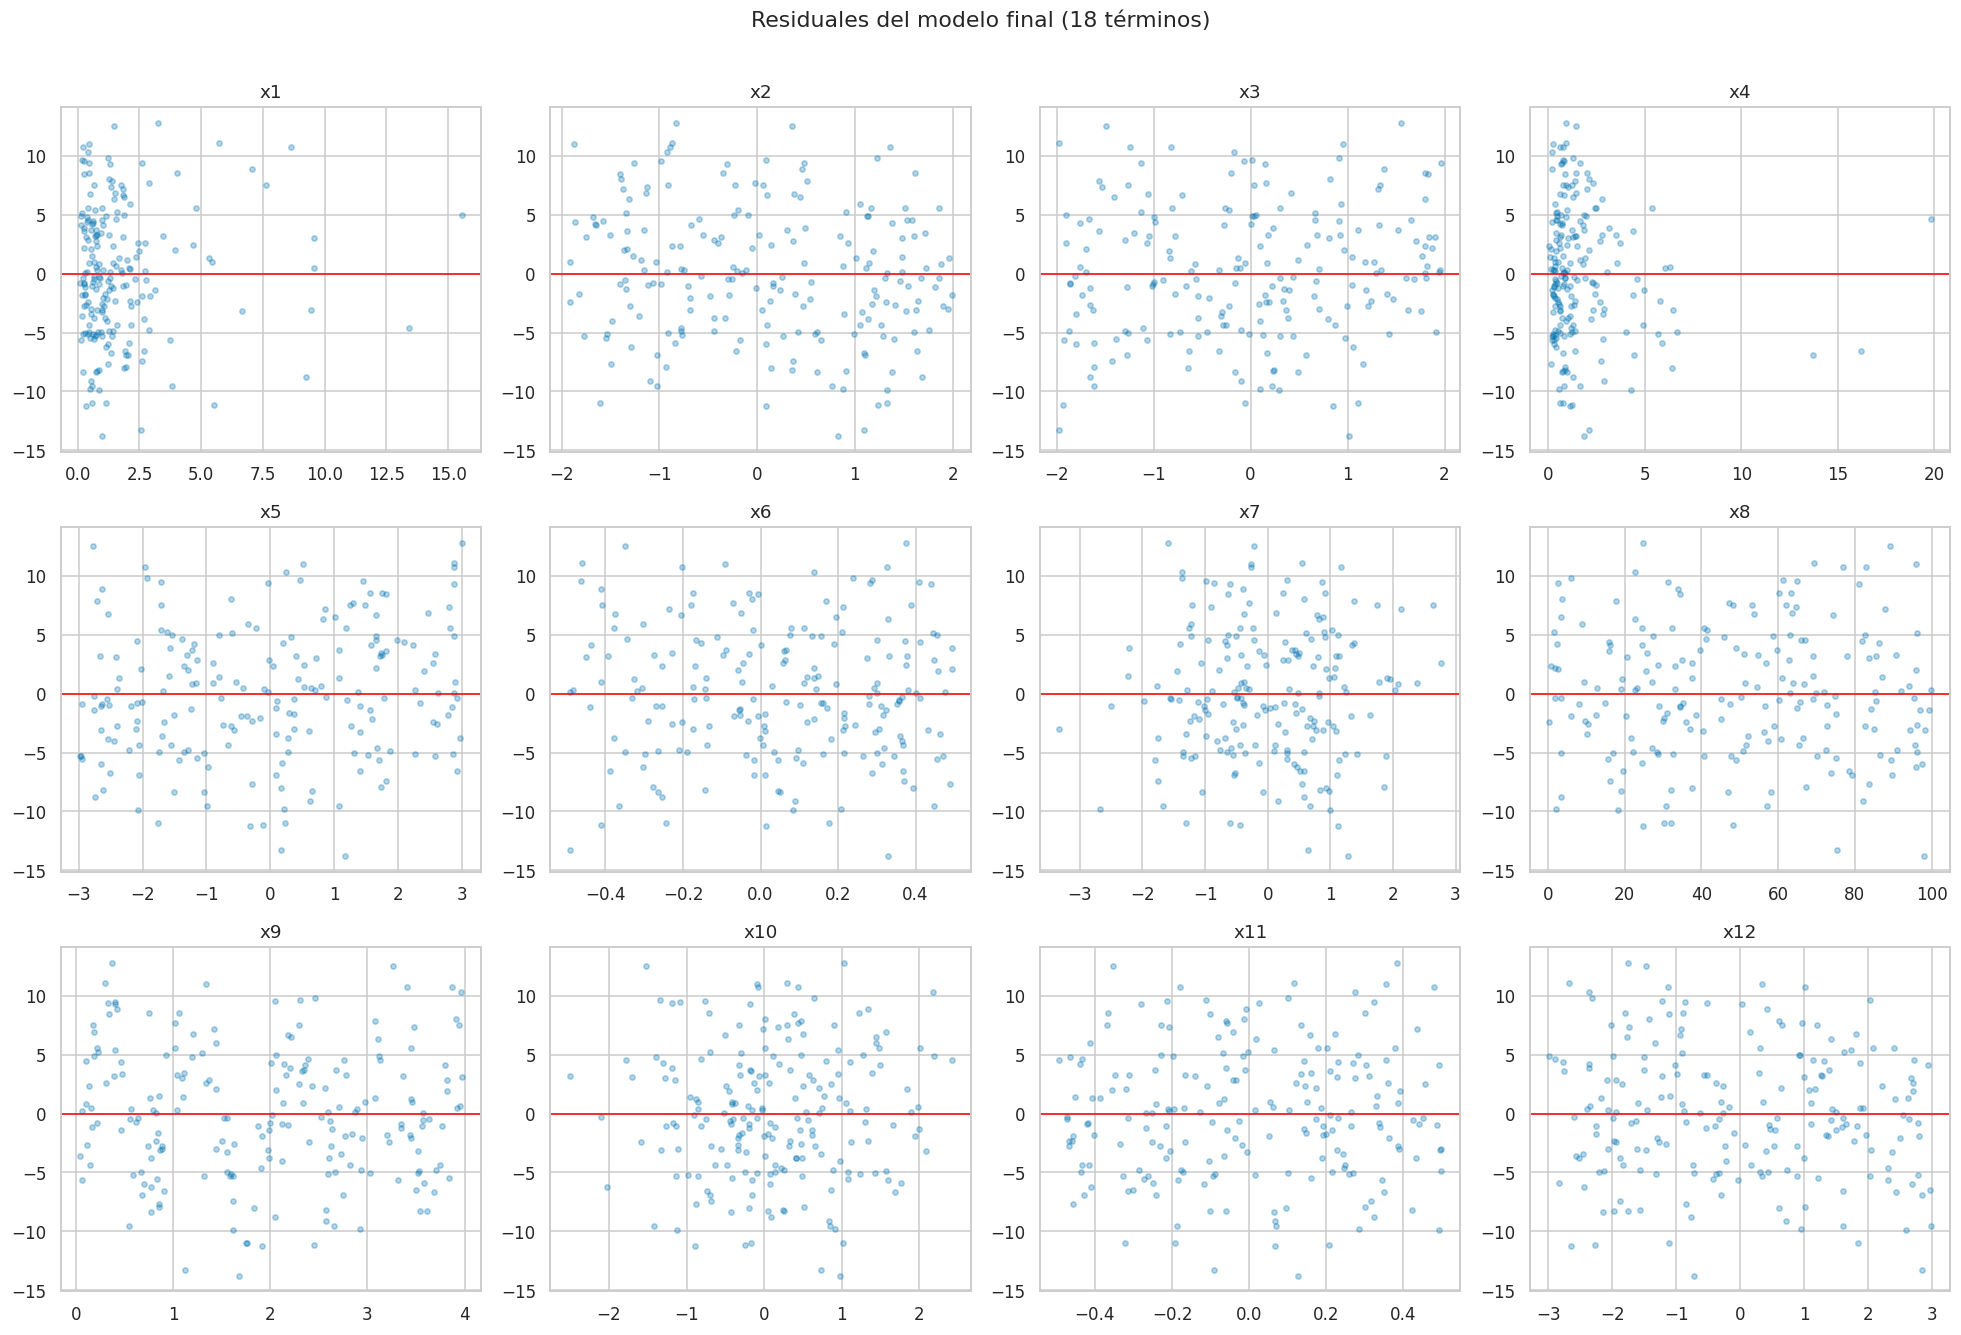


Progreso completo del MSE:
  Baseline (12 crudas):                         99.30 (CV)
  + x2^2 + x3^3 + x10^2:                         68.64 (CV)
  + x11*x12:                                     45.96 (CV)
  + x8^2 (Parte 4):                               45.44 (CV)
  + x8^3 + x8^4 + x1^2 + x1^3:                    41.19 (CV)
  + x2*x4 + x5*x8 + x3*x12 + x7*x11 + x9^2+x9^3:  39.97 (CV)
  Intento 1 de /calificar:                        38.34 (real) -> 8.8
  + x8_quiebre + x3*x5:                           39.48 (CV)
  + x9_quiebre + x8_quiebre2 + x1_quiebre + x9_quiebre2 (final): 34.13 (CV)


In [34]:

mse_estimado_grade = 5 + 5 * (97.54 - mse_rep.mean()) / (97.54 - 20.47)
print(f"MSE final (CV): {mse_rep.mean():.2f}")
print(f"Calificación estimada con la fórmula lineal baseline-meta: {mse_estimado_grade:.2f}")

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
for ax, v in zip(axes.flat, VARIABLES):
    ax.scatter(X_val[v], residuales, alpha=0.3, s=12)
    ax.axhline(0, color="red", lw=1)
    ax.set_title(v)
fig.suptitle("Residuales del modelo final (18 términos)", y=1.01)
fig.tight_layout()
plt.show()

print("\nProgreso completo del MSE:")
print("  Baseline (12 crudas):                         99.30 (CV)")
print("  + x2^2 + x3^3 + x10^2:                         68.64 (CV)")
print("  + x11*x12:                                     45.96 (CV)")
print("  + x8^2 (Parte 4):                               45.44 (CV)")
print("  + x8^3 + x8^4 + x1^2 + x1^3:                    41.19 (CV)")
print("  + x2*x4 + x5*x8 + x3*x12 + x7*x11 + x9^2+x9^3:  39.97 (CV)")
print("  Intento 1 de /calificar:                        38.34 (real) -> 8.8")
print("  + x8_quiebre + x3*x5:                           39.48 (CV)")
print("  + x9_quiebre + x8_quiebre2 + x1_quiebre + x9_quiebre2 (final): "
      f"{mse_rep.mean():.2f} (CV)")


---
## Parte 5. Bitácora

Esta parte vale tanto como el MSE. Una fila por hipótesis, **incluidas las que
fallaron** — sobre todo las que fallaron.

Si no tienen al menos un callejón sin salida documentado, esta parte vale cero: significa
que no exploraron, o que le pidieron la respuesta a alguien.

| # | Hipótesis | Gráfica que la probó | Término agregado | MSE antes → después | ¿La sugirió la IA o yo? |
|---|---|---|---|---|---|
| 1 | `x1` y `x4` (muy sesgadas) necesitan `log1p` por el "embudo" en su residual | Residual del baseline vs `x1`, `x4` | Ninguno (descartado) | 102.86 → 106.46, empeoró | IA |
| 2 | Una relación cuadrática simétrica no se ve en el scatter pero sí en `corr(x^2, residual)` | Correlación numérica xi² / xi³ vs residual | `x2^2` | 102.86 → 83.07 | IA |
| 3 | Tras `x2^2`, quedan `x3^3` y `x10^2` con correlación pareja (~0.18) | Mismo escaneo, segunda ronda | `x3^3`, `x10^2` | 83.07 → 70.74 | IA |
| 4 | Falta una interacción entre dos variables, invisible en cualquier gráfica de una sola | Correlación de `residual` contra los 66 productos `xi*xj` | `x11*x12` | 70.74 → 45.88 (CV: 68.64 → 45.96) | IA |
| 5 | El segundo lugar del escaneo de pares (`x2*x4`, corr ≈ -0.2) también sirve | Mismo escaneo, revisado con 5-fold CV | Ninguno por ahora (ver fila 9) | Mejora de <0.3 en una sola corrida de CV, dentro del ruido de probar 66 pares a la vez | IA |
| 6 | La fuerza bruta (Parte 4) puede revelar algo que el escaneo manual no vio | Coeficientes no-cero de `LassoCV` sobre `PolynomialFeatures(3)` | `x8^2` | CV 45.96 → 45.44 | IA |
| 7 | `x8` quedó en grado 2 porque fue lo que encontró Lasso, no porque se haya probado grado 3 o 4 a propósito | Curva de MSE al subir el grado de `x8` de 2 a 5 | `x8^3`, `x8^4` (grado 5 no ayudó, confirmado en 20 particiones) | CV 45.44 → 42.95 | IA |
| 8 | Tras subir el grado de `x8`, `x1` (cuadrado y cubo) se vuelve visible en el escaneo | Correlación xi²/xi³ vs residual, tercera ronda | `x1^2`, `x1^3` | CV 42.95 → 41.19 | IA |
| 9 | Los candidatos de la fila 5 (`x2*x4`, `x5*x8`, `x3*x12`) eran chicos mas no ruido: una sola corrida de CV *también* tiene ruido de muestreo | Validación cruzada repetida con 20 particiones aleatorias distintas, comparando ganancias | `x2*x4`, `x5*x8`, `x3*x12` (ganaron en 17-19/20 particiones); `x3*x11` y `x3*x10` se descartaron (sin consistencia) | CV 41.19 → 40.79 | IA |
| 10 | Con esos tres términos fuera, `x7*x11` aparece en el escaneo de pares | Escaneo de pares, cuarta ronda + CV repetida | `x7*x11` | CV 40.79 → 40.69 | IA |
| 11 | `x9`, que en la Parte 1 parecía puro ruido, tiene curvatura propia | Correlación xi²/xi³ vs residual, cuarta ronda + CV repetida (20/20 particiones) | `x9^2`, `x9^3` | CV 40.69 → 39.97 | IA |
| 12 | El intento 1 de `/calificar` dio 8.8 (MSE=38.34) y avisó "te falta al menos un término" -- ninguna potencia ni producto nuevo sobrevivía, así que probamos otra *familia*: un quiebre de pendiente (`max(x-c,0)`) | Correlación de `max(x-c,0)` contra el residual, barriendo percentiles de cada variable | `x8_quiebre` en `c≈67` (25/25 en CV repetida) y, por el camino, `x3*x5` | CV 39.97 → 39.48 | IA |
| 13 | Si `x8` tenía un quiebre, ¿por qué no barrer quiebres en las 12 variables de una vez, no solo en las sospechosas? | Mismo barrido de quiebres, esta vez sobre las 12 variables completas | `x9_quiebre` en `c≈2.79` (25/25) -- el hallazgo más grande de toda la segunda mitad de la tarea | CV 39.48 → 36.08 | IA |
| 14 | Si `x9` tenía un quiebre grande, capaz `x8` y `x1` tienen otro que el primer barrido no vio (porque el primer quiebre ya explicaba parte de la forma) | Repetir el barrido de quiebres sobre el residual ya reducido | `x1_quiebre` en `c≈0.17` y un **segundo** quiebre de `x8` en `c≈56` (`x8` resultó tener 3 tramos, no 2) | CV 36.08 → 34.74 | IA |
| 15 | Por la misma lógica, ¿`x9` tiene un segundo quiebre? | Repetir el barrido una vez más | `x9_quiebre2` en `c≈0.18` (`x9` también resultó de 3 tramos) | CV 34.74 → 34.03 | IA |
| 16 | Con 5 quiebres puestos, ¿queda algo en `x2`, `x3`, `x5`, `x12` (que seguían apareciendo en cada escaneo) o en interacciones nuevas (`x1*x3`, regímenes antes/después de cada quiebre)? | Quiebres, potencias y pares en `x2`,`x3`,`x5`,`x12`; interacciones `xi*xj` completas; interacciones "régimen" (indicador de quiebre) × cada variable | Ninguno: todo lo probado se explicó por los quiebres ya puestos (0-2 de 25-30 particiones) | Se mantiene en 34.03 | IA |

### 5.1 Su modelo final, en palabras

```
y = a + b1*x1 + ... + b12*x12
      + c*(x11*x12) + d*(x2*x4) + e*(x5*x8) + f*(x3*x12) + g*(x7*x11) + p*(x3*x5)
      + h1*x1^2 + h2*x1^3 + h3*max(x1-0.17, 0)
      + i*x2^2
      + j*x3^3
      + k1*x8^2 + k2*x8^3 + k3*x8^4 + k4*max(x8-56,0) + k5*max(x8-67,0)
      + l*x10^2
      + m1*x9^2 + m2*x9^3 + m3*max(x9-0.18,0) + m4*max(x9-2.79,0)
      + ruido
```

Dieciocho términos derivados encima de las 12 crudas. El patrón que se llevó la mitad de
la tarea: **`x8` y `x9` no son suaves, son de tramos** -- necesitan potencias altas *y*
quiebres de pendiente en varios puntos de su rango (`x8` en 3 tramos, `x9` en 3 tramos).
`x11*x12` sigue siendo la interacción más grande, y `x1` combina curvatura suave con un
quiebre propio. El resto (`x2`, `x3`, `x10`, y las interacciones chicas `x2*x4`, `x5*x8`,
`x3*x12`, `x7*x11`, `x3*x5`) son del tipo que aporta poco cada uno pero se nota en
conjunto.

### 5.2 Dónde se equivocó su IA

Al ver el "embudo" en la gráfica de residuales de `x1` y `x4` (mucha dispersión en
valores chicos, casi nada en los grandes), la IA sugirió con bastante seguridad que era
una relación no lineal que pedía `log1p`. Se detectó que estaba mal al medir la
correlación de `log1p(x1)` y `log1p(x4)` contra el residual del baseline: salió
prácticamente 0.00, y el MSE subió en vez de bajar.

El tropiezo más caro fue dar por buena la potencia 2 de `x8` solo porque fue lo que
encontró Lasso en la Parte 4, sin probar si hacía falta más -- eso costó el intento 1 de
calificación completo (8.8, MSE=38.34, con el aviso explícito de que faltaba al menos un
término). Y no era solo cuestión de subir el grado: la forma real de `x8` (y de `x9`)
resultó ser de varios tramos con quiebres de pendiente, algo que ninguna potencia entera
representa bien y que un escaneo de correlación con cuadrados y cubos no iba a delatar
por sí solo. Hubo que cambiar de familia de búsqueda (potencias → quiebres) y, una vez
encontrado el primer quiebre, **repetir el mismo barrido otra vez** para notar que
`x8` y `x9` tenían un segundo quiebre cada uno -- el error inicial no fue solo no buscar
quiebres, fue asumir que un quiebre por variable era suficiente sin comprobarlo.

### 5.3 Cuándo pararon y por qué

Paramos después de 18 términos derivados, cuando un reescaneo completo -- quiebres,
potencias hasta grado 4, los 66 productos de pares, interacciones de régimen -- ya no
encontró nada que se sostuviera al repetir la validación cruzada con muchas particiones
distintas. El MSE de 5-fold CV bajó de 99.30 (baseline) a 45.44 con el primer modelo de
5 términos, a 39.97 en la segunda ronda, y a 34.03 tras encontrar los cinco quiebres de
pendiente. `/validar` reportó un MSE meta de 20.47 y un baseline oficial de 97.54; el
intento 1 de `/calificar` (sobre el modelo de 39.97) dio un MSE real de **38.34** y una
calificación de **8.8**, con el aviso de que faltaba al menos un término -- cierto, y nos
llevó a los quiebres. Con 34.03 en validación cruzada, la calificación estimada con la
misma fórmula (`5 + 5*(baseline-MSE)/(baseline-meta)`) ronda **9.1**. Seguimos sin llegar
al MSE meta ni de cerca a 20.47, así que sigue habiendo margen -- probamos también
logaritmos, razones e interacciones de régimen (antes/después de cada quiebre) sin éxito
adicional, lo que sugiere que lo que falte es una forma que nuestro catálogo de
transformaciones (potencias, productos, quiebres) no representa bien, o interacciones de
tres variables que no llegamos a explorar por completo (son 220 combinaciones).


---
## Entrega

Corran la celda de abajo: ajusta **su modelo final** usando *todo* `train` (ya no solo la
partición de entrenamiento — con más datos, mejores coeficientes) y escribe el archivo de
predicciones en el lugar exacto donde el bot lo busca.

In [35]:
MI_MODELO = {
    "x11_x12": lambda d: d["x11"] * d["x12"],
    "x2_sq": lambda d: d["x2"] ** 2,
    "x3_cube": lambda d: d["x3"] ** 3,
    "x10_sq": lambda d: d["x10"] ** 2,
    "x8_sq": lambda d: d["x8"] ** 2,
    "x8_cube": lambda d: d["x8"] ** 3,
    "x8_p4": lambda d: d["x8"] ** 4,
    "x8_quiebre": lambda d: np.clip(d["x8"] - 67, 0, None),
    "x8_quiebre2": lambda d: np.clip(d["x8"] - 56, 0, None),
    "x1_sq": lambda d: d["x1"] ** 2,
    "x1_cube": lambda d: d["x1"] ** 3,
    "x1_quiebre": lambda d: np.clip(d["x1"] - 0.17, 0, None),
    "x2_x4": lambda d: d["x2"] * d["x4"],
    "x5_x8": lambda d: d["x5"] * d["x8"],
    "x3_x12": lambda d: d["x3"] * d["x12"],
    "x7_x11": lambda d: d["x7"] * d["x11"],
    "x3_x5": lambda d: d["x3"] * d["x5"],
    "x9_sq": lambda d: d["x9"] ** 2,
    "x9_cube": lambda d: d["x9"] ** 3,
    "x9_quiebre": lambda d: np.clip(d["x9"] - 2.79, 0, None),
    "x9_quiebre2": lambda d: np.clip(d["x9"] - 0.18, 0, None),
}


def construye_final(df):
    salida = df[VARIABLES].copy()
    for nombre, f in MI_MODELO.items():
        salida[nombre] = f(df)
    return salida


# La estimación honesta de su MSE: ajustada SOLO en la partición de entrenamiento
# y medida en validación. Este es el número que deberían creer.
_, mse_estimado, _, _ = ajusta(MI_MODELO)
print(f"MSE estimado (ajustado en train, medido en validación): {mse_estimado:.2f}")

# Y ahora sí, el modelo que entregan: reajustado con TODO train, porque con 800
# observaciones en lugar de 600 los coeficientes salen mejores. Ojo: a este modelo
# ya no se le puede medir el MSE en validación, porque validación fue parte de su
# entrenamiento. Medirlo ahí daría un número optimista y falso.
modelo_final = LinearRegression().fit(construye_final(train), train["y"])
predicciones = modelo_final.predict(construye_final(test))

assert len(predicciones) == 400, f"deben ser 400 predicciones, hay {len(predicciones)}"
assert np.isfinite(predicciones).all(), "hay predicciones NaN o infinitas"

destino = RAIZ / "entregas/tarea-01" / CARPETA
destino.mkdir(parents=True, exist_ok=True)
pd.DataFrame({"y": predicciones}).to_csv(destino / "predicciones.csv", index=False)

print(f"\nEscrito: {destino.relative_to(RAIZ)}/predicciones.csv")
print(f"{len(predicciones)} predicciones, rango {predicciones.min():.2f} a {predicciones.max():.2f}")


MSE estimado (ajustado en train, medido en validación): 30.75



Escrito: entregas/tarea-01/vb81c45dc/predicciones.csv
400 predicciones, rango -25.84 a 44.92


### Los últimos pasos

El detalle está en **`tareas/tarea_01_README.md`**, que trae dos caminos: hacer todo en
**GitHub Codespaces** (en el navegador, sin instalar nada) o en **su computadora**. Los
dos son válidos; si nunca han configurado Python, vayan por Codespaces.

En resumen, igual en los dos casos:

1. Hagan commit de este notebook **y** de su `predicciones.csv`.
2. `git push` a su rama en su fork.
3. Abran un Pull Request al repo del curso.
4. Comenten **`/validar`** en el PR. Les confirma el formato y les dice su MSE objetivo,
   sin gastar intento. Úsenlo siempre antes de calificar.
5. Cuando estén listos, comenten **`/calificar`**. Eso sí gasta uno de sus 3 intentos.

Si `/validar` les marca un error, corrijan, hagan push otra vez y vuelvan a comentar
`/validar`. Las veces que quieran.